# 03 — Causal Modelling: DML + Causal Forest

Estimates the **Average Treatment Effect** (ATE) of daily/weekly AI-tool adoption on job satisfaction (0–10) using **Double / Debiased Machine Learning** (Chernozhukov et al. 2018), then recovers **Conditional Average Treatment Effects** (CATEs) with a **Causal Forest** (Wager & Athey 2018) to test heterogeneity hypotheses.

| Hypothesis | Dimension | Predicted direction |
|---|---|---|
| H1a | WorkExp ≤ 5 yrs (junior) | Positive effect |
| H1b | WorkExp ≥ 10 yrs (senior) | Near-zero or negative |
| H2  | OrgSize | Effect increases with org size |

**Data:** `data/processed/analysis.parquet` — N = 19,320 (adopters 15,971, non-adopters 3,349)

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.dml import CausalForestDML

FIGURES = Path("../results/figures")
TABLES  = Path("../results/tables")
DATA    = Path("../data/processed")
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)
print("Packages loaded.")

Packages loaded.


## Load & Describe Analysis Frame

In [2]:
df = pd.read_parquet(DATA / "analysis.parquet")
df_full = df.copy()   # full frame including plan_to_soon, used in robustness section

# Main analysis sample: adopters and non-adopters only (plan_to_soon → treated=NaN)
if "adoption_status" in df.columns:
    df = df[df["adoption_status"] != "plan_to_soon"].reset_index(drop=True).copy()

print(f"Full parquet: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")
print(f"Main analysis sample: {df.shape[0]:,} rows")
print(f"  Adopters     (T=1): {(df.treated==1).sum():,}  ({(df.treated==1).mean():.1%})")
print(f"  Non-adopters (T=0): {(df.treated==0).sum():,}  ({(df.treated==0).mean():.1%})")
print()

naive_diff = (df.loc[df.treated==1,"JobSat"].mean()
              - df.loc[df.treated==0,"JobSat"].mean())
print(f"JobSat — overall mean: {df.JobSat.mean():.3f}  std: {df.JobSat.std():.3f}")
print(f"  Adopters mean   : {df.loc[df.treated==1,'JobSat'].mean():.3f}")
print(f"  Non-adopters mean: {df.loc[df.treated==0,'JobSat'].mean():.3f}")
print(f"  Naïve difference : {naive_diff:+.4f}  (unadjusted, biased)")

Full parquet: 20,373 rows × 22 columns
Main analysis sample: 19,320 rows
  Adopters     (T=1): 15,971  (82.7%)
  Non-adopters (T=0): 3,349  (17.3%)

JobSat — overall mean: 7.294  std: 1.911
  Adopters mean   : 7.307
  Non-adopters mean: 7.229
  Naïve difference : +0.0779  (unadjusted, biased)


## Step 1 · Feature Engineering

One-hot encode nominal covariates for the ML nuisance models.  
Countries with **< 50 respondents** are collapsed to `"Other"` to avoid extremely sparse dummies.
All numeric/ordinal covariates are already clean (median-imputed in notebook 02); missing-value indicators are included in X.

In [3]:
ORDINAL  = ["OrgSize", "Age", "EdLevel"]
NUMERIC  = ["WorkExp", "YearsCode", "CompLog"]
MISS_IND = ["WorkExp_missing", "YearsCode_missing", "CompLog_missing"]
NOMINAL  = ["DevType", "Country", "Industry", "RemoteWork", "ICorPM"]
SECONDARY = ["AIThreat", "AISent", "AIAcc", "AIComplex"]

df = df.copy()

# Collapse rare countries
country_vc = df["Country"].value_counts()
rare_countries = country_vc[country_vc < 50].index
df["Country"] = df["Country"].where(~df["Country"].isin(rare_countries), other="Other")
n_named = (df["Country"] != "Other").sum()
print(f"Country: {n_named:,} in named countries, {(df['Country']=='Other').sum():,} in 'Other'")

# One-hot encode (keep all categories, no drop_first — tree models don't need it)
X_nominal = pd.get_dummies(df[NOMINAL], drop_first=False, dtype=float)
X_numeric  = df[ORDINAL + NUMERIC + MISS_IND].astype(float)
X = pd.concat([X_numeric, X_nominal], axis=1).reset_index(drop=True)
feature_names = X.columns.tolist()

Y = df["JobSat"].values.astype(float)
T = df["treated"].values.astype(float)

print(f"\nFeature matrix X: {X.shape[0]:,} × {X.shape[1]}")
print(f"  Numeric/ordinal + indicators : {len(ORDINAL+NUMERIC+MISS_IND)}")
print(f"  One-hot dummies (nominal)    : {X_nominal.shape[1]}")
print(f"\nAny NaN in X: {X.isnull().sum().sum()}")

Country: 18,205 in named countries, 1,115 in 'Other'

Feature matrix X: 19,320 × 122
  Numeric/ordinal + indicators : 9
  One-hot dummies (nominal)    : 113

Any NaN in X: 0


## Step 2 · Overlap / Positivity Check

A key identifying assumption for DML and causal forests is **overlap** (positivity):  
every unit must have a non-zero probability of being in either treatment arm.  
We estimate propensity scores $\hat{e}(X) = P(T=1 \mid X)$ via logistic regression and inspect both groups' distributions.

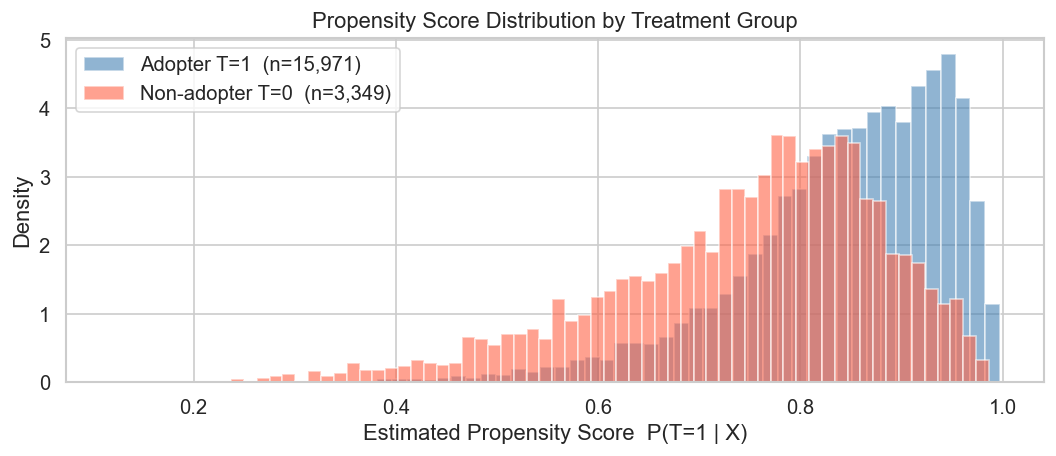

PS range  : [0.118, 0.997]
Mean PS   : 0.827  (marginal treatment rate: 0.827)
Extreme PS (< 0.05 or > 0.95): 11.6% of obs



In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

ps_lr = LogisticRegression(max_iter=1000, C=0.1, random_state=42, n_jobs=-1)
ps_lr.fit(X_scaled, T)
ps = ps_lr.predict_proba(X_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ps[T==1], bins=60, alpha=0.6, density=True,
        label=f"Adopter T=1  (n={int(T.sum()):,})", color="steelblue")
ax.hist(ps[T==0], bins=60, alpha=0.6, density=True,
        label=f"Non-adopter T=0  (n={int((1-T).sum()):,})", color="tomato")
ax.set_xlabel("Estimated Propensity Score  P(T=1 | X)")
ax.set_ylabel("Density")
ax.set_title("Propensity Score Distribution by Treatment Group")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "ps_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

pct_extreme = ((ps < 0.05) | (ps > 0.95)).mean()
print(f"PS range  : [{ps.min():.3f}, {ps.max():.3f}]")
print(f"Mean PS   : {ps.mean():.3f}  (marginal treatment rate: {T.mean():.3f})")
print(f"Extreme PS (< 0.05 or > 0.95): {pct_extreme:.1%} of obs")
print()
if pct_extreme > 0.10:
    print("WARNING: >10% of obs have extreme PS. Consider trimming or reporting robustness.")
else:
    print("Overlap looks adequate (< 10% extreme PS).")

## Step 3 · Double / Debiased Machine Learning — ATE

We implement the **partially linear regression** (PLR) formulation (Robinson 1988; Chernozhukov et al. 2018):

$$Y_i = \theta \cdot T_i + g(X_i) + \varepsilon_i$$

The two-step procedure:
1. **Nuisance estimation** — obtain cross-fitted residuals $\tilde{Y} = Y - \hat{g}(X)$ and $\tilde{T} = T - \hat{m}(X)$ using **5-fold cross-fitting** with LightGBM.
2. **ATE via OLS** — regress $\tilde{Y}$ on $\tilde{T}$; the coefficient is $\hat{\theta}$ with heteroskedasticity-robust (HC3) standard errors.

Cross-fitting prevents regularisation bias from contaminating the treatment-effect estimate.

In [5]:
lgbm_params = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                    colsample_bytree=0.8, subsample=0.8, verbose=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-fitting outcome model  (LGBMRegressor, 5 folds)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Y_hat = cross_val_predict(
        LGBMRegressor(**lgbm_params, random_state=42), X.values, Y, cv=kf)

print("Cross-fitting treatment model (LGBMClassifier, 5 folds)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    T_hat = cross_val_predict(
        LGBMClassifier(**lgbm_params, random_state=42), X.values, T, cv=kf,
        method="predict_proba")[:, 1]

Y_res = Y - Y_hat   # partialled-out outcome
T_res = T - T_hat   # partialled-out treatment

r2_y = 1 - np.var(Y_res) / np.var(Y)
r2_t = 1 - np.var(T_res) / np.var(T)
print(f"\nNuisance fit quality:")
print(f"  R² for Y model: {r2_y:.3f}  (more variation explained → tighter ATE CI)")
print(f"  R² for T model: {r2_t:.3f}")

Cross-fitting outcome model  (LGBMRegressor, 5 folds)...


Cross-fitting treatment model (LGBMClassifier, 5 folds)...



Nuisance fit quality:
  R² for Y model: 0.003  (more variation explained → tighter ATE CI)
  R² for T model: 0.060


In [6]:
# OLS on residuals: ATE with HC3 robust SEs
Tres_df = pd.DataFrame({"T_res": T_res})
ols = sm.OLS(Y_res, sm.add_constant(Tres_df)).fit(cov_type="HC3")

ate    = float(ols.params["T_res"])
ate_se = float(ols.bse["T_res"])
ci_lo  = float(ols.conf_int().loc["T_res", 0])
ci_hi  = float(ols.conf_int().loc["T_res", 1])
z_stat = float(ols.tvalues["T_res"])
p_val  = float(ols.pvalues["T_res"])
ate_std = ate / Y.std()

ate_rel = ate / Y.mean() * 100   # % of sample mean
print("=" * 60)
print("Double ML — Average Treatment Effect (ATE)")
print("=" * 60)
print(f"ATE      = {ate:+.4f} pts  (0–10 JobSat scale)")
print(f"           = {ate_rel:+.2f}% of sample mean ({Y.mean():.2f})")
print(f"           = d = {ate_std:.3f}  (Cohen's d; < 0.1 is trivial)")
print(f"95% CI   = [{ci_lo:+.4f}, {ci_hi:+.4f}] pts")
print(f"z-stat   = {z_stat:+.3f},  p = {p_val:.4f}")
print()
print(f"Naïve OLS (unadjusted): {naive_diff:+.4f} pts  (d = {naive_diff/Y.std():.3f})")
print(f"DML (adjusted)        : {ate:+.4f} pts  (d = {ate_std:.3f})")
print()
print("Central finding: on average the effect is small — the story is heterogeneity.")


Double ML — Average Treatment Effect (ATE)
ATE      = +0.1237 pts  (0–10 JobSat scale)
           = +1.70% of sample mean (7.29)
           = d = 0.065  (Cohen's d; < 0.1 is trivial)
95% CI   = [+0.0474, +0.1999] pts
z-stat   = +3.177,  p = 0.0015

Naïve OLS (unadjusted): +0.0779 pts  (d = 0.041)
DML (adjusted)        : +0.1237 pts  (d = 0.065)

Central finding: on average the effect is small — the story is heterogeneity.


## Step 4 · Causal Forest DML — CATEs

**CausalForestDML** (Wager & Athey 2018; Athey et al. 2019) extends DML by using the cross-fitted residuals $\tilde{Y}, \tilde{T}$ as the "pseudo-outcome" for a forest that estimates heterogeneous $\tau(X)$:

$$\hat{\tau}(x) = \text{CausalForest}(\tilde{Y} / \tilde{T},\ X)$$

Key settings:
- **n_estimators = 2000** honest trees (half sample for splitting, half for estimation)
- **5-fold** cross-fitting for nuisance models (same LightGBM as DML)
- `min_samples_leaf = 10` to ensure stable leaf estimates
- Confidence intervals via the infinitesimal jackknife for forests (Wager et al. 2014)

*This cell takes ~3–6 minutes to run.*

In [7]:
import joblib

cates_path    = DATA / "cates.npy"
cf_model_path = DATA / "cf_model.joblib"

if cates_path.exists() and cf_model_path.exists():
    print("Loading cached CATEs and CF model from disk ...")
    cates    = np.load(cates_path)
    ci_lower = np.load(DATA / "cates_ci_lower.npy")
    ci_upper = np.load(DATA / "cates_ci_upper.npy")
    cf       = joblib.load(cf_model_path)
    print("Loaded.")
else:
    cf = CausalForestDML(
        model_y    = LGBMRegressor(**lgbm_params, random_state=42),
        model_t    = LGBMClassifier(**lgbm_params, random_state=42),
        n_estimators = 2000,
        cv           = 5,
        random_state = 42,
        inference    = True,
        discrete_treatment = True,
        min_samples_leaf = 10,
    )
    print("Fitting Causal Forest DML (2000 trees, 5-fold cross-fitting) ...")
    print("This will take 5-10 minutes ...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cf.fit(Y, T, X=X.values)
    print("Done.")

    cates    = cf.effect(X.values)
    ci_lower, ci_upper = cf.effect_interval(X.values, alpha=0.05)

    np.save(cates_path, cates)
    np.save(DATA / "cates_ci_lower.npy", ci_lower)
    np.save(DATA / "cates_ci_upper.npy", ci_upper)
    joblib.dump(cf, cf_model_path, compress=3)
    print("CATEs and CF model saved to data/processed/")

print(f"\nCATEs  mean: {cates.mean():.4f}  std: {cates.std():.4f}")
print(f"  % > 0  : {(cates > 0).mean():.1%}")
print(f"  % > 0.1: {(cates > 0.1).mean():.1%}")
print(f"\nATE from CausalForest (mean of CATEs): {cates.mean():.4f}")
print(f"ATE from DML (primary estimate)       : {ate:.4f}")


Loading cached CATEs and CF model from disk ...


Loaded.

CATEs  mean: 0.1355  std: 0.2162
  % > 0  : 74.4%
  % > 0.1: 57.2%

ATE from CausalForest (mean of CATEs): 0.1355
ATE from DML (primary estimate)       : 0.1237


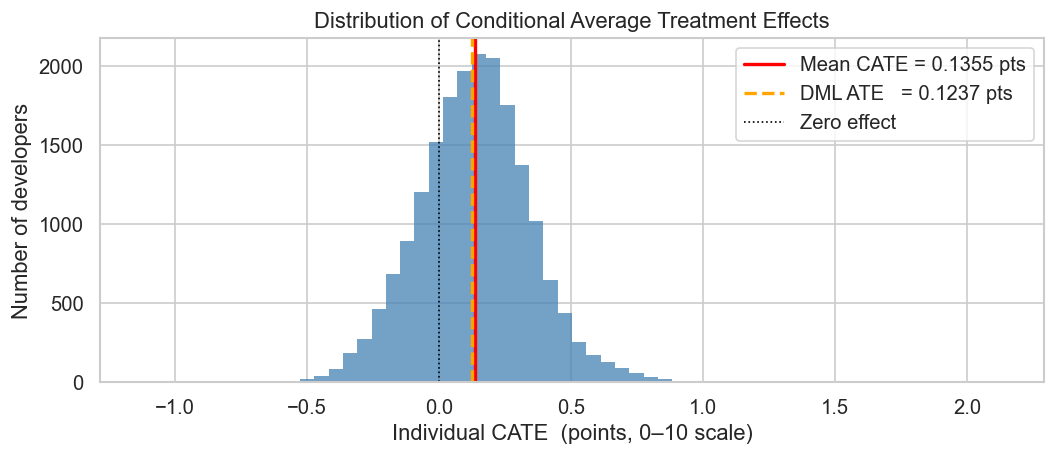

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cates, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
ax.axvline(cates.mean(), color="red",   lw=2, ls="-",
           label=f"Mean CATE = {cates.mean():.4f} pts")
ax.axvline(ate,           color="orange",lw=2, ls="--",
           label=f"DML ATE   = {ate:.4f} pts")
ax.axvline(0,                  color="black", lw=1, ls=":", label="Zero effect")
ax.set_xlabel("Individual CATE  (points, 0–10 scale)")
ax.set_ylabel("Number of developers")
ax.set_title("Distribution of Conditional Average Treatment Effects")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "cate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 5 · Heterogeneity by Developer Experience

We bin `WorkExp` into three groups and estimate OLS-on-residuals GATEs.
Effects are reported in **points** on the 0–10 JobSat scale.

> **Scope**: All estimates are conditional on observables X. Unobserved factors
> (technology enthusiasm, employer AI culture) could confound individual-level estimates.


OLS-GATE by experience group (primary inference, HC3):
Group             n GATE (pts)       SE               95% CI       z        p
--------------------------------------------------------------------------------
0-2 yrs       1,509    -0.2490   0.1575   [-0.5577, +0.0598]   -1.58   0.1140  ns
3-20 yrs     13,892    +0.2079   0.0477   [+0.1144, +0.3014]   +4.36   0.0000  ***
21+ yrs       3,919    -0.0135   0.0739   [-0.1583, +0.1314]   -0.18   0.8555  ns

Contrast: GATE(3-20 yrs) vs GATE(0-2 yrs)
  Diff = +0.4569 pts,  z = +2.78,  p = 0.0055  **

Note: the 3–20 yr bin averages over a near-zero sub-segment (≈3–5 yrs)
  and the peak segment (≈6–20 yrs); the true peak contrast is likely understated.
  Bin boundaries 0-2 / 3-20 / 21+ are fixed per analysis plan.


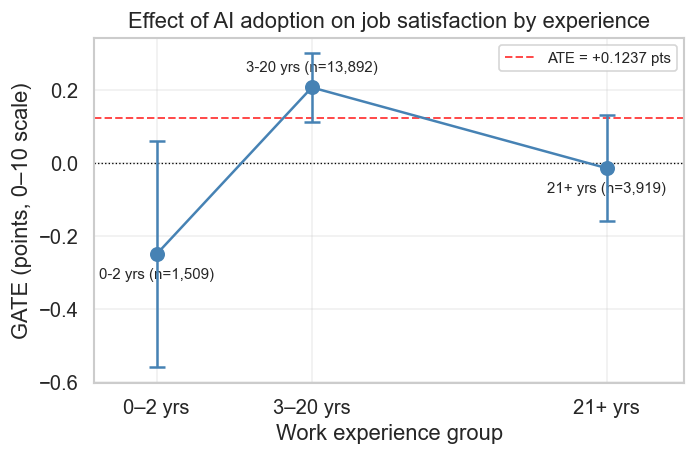

In [9]:
work_exp  = df["WorkExp"].values
miss_flag = df["WorkExp_missing"].values.astype(bool)

EXP_BINS   = [0, 2, 20, 100]
EXP_LABELS = ["0-2 yrs", "3-20 yrs", "21+ yrs"]
EXP_MIDS   = [1, 11, 30]   # midpoints for plot x-axis

exp_groups = pd.cut(pd.Series(work_exp), bins=EXP_BINS,
                    labels=EXP_LABELS, right=True, include_lowest=True)

from scipy.stats import norm as _norm

rows = []
for grp, mid in zip(EXP_LABELS, EXP_MIDS):
    mask = (exp_groups == grp).values
    if mask.sum() < 20:
        continue
    cf_mean = float(cates[mask].mean())
    T_gdf   = pd.DataFrame({"T_res": T_res[mask]})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ols_g = sm.OLS(Y_res[mask], sm.add_constant(T_gdf)).fit(cov_type="HC3")
    gate_g = float(ols_g.params["T_res"])
    se_g   = float(ols_g.bse["T_res"])
    rows.append({
        "group": grp, "mid": mid, "n": mask.sum(),
        "cf_cate": cf_mean,
        "gate_ols": gate_g,
        "se": se_g,
        "ci_lo": gate_g - 1.96*se_g,
        "ci_hi": gate_g + 1.96*se_g,
    })

res_exp = pd.DataFrame(rows)
res_exp.to_csv(TABLES / "cate_by_experience.csv", index=False)

# ── Print table ────────────────────────────────────────────────────────────────
print("OLS-GATE by experience group (primary inference, HC3):")
print(f"{'Group':12s} {'n':>6s} {'GATE (pts)':>10s} {'SE':>8s} {'95% CI':>20s} {'z':>7s} {'p':>8s}")
print("-" * 80)
for _, r in res_exp.iterrows():
    z = r["gate_ols"] / r["se"]
    p = 2 * (1 - _norm.cdf(abs(z)))
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ci_str = f"[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]"
    print(f"{str(r['group']):12s} {int(r['n']):>6,d} {r['gate_ols']:>+10.4f} "
          f"{r['se']:>8.4f} {ci_str:>20s} {z:>+7.2f} {p:>8.4f}  {sig}")

# ── Key contrast: mid vs junior ────────────────────────────────────────────────
r_jun = res_exp[res_exp["group"].astype(str) == "0-2 yrs"].iloc[0]
r_mid = res_exp[res_exp["group"].astype(str) == "3-20 yrs"].iloc[0]
diff_ols    = float(r_mid["gate_ols"]) - float(r_jun["gate_ols"])
se_diff_ols = (r_jun["se"]**2 + r_mid["se"]**2) ** 0.5
z_diff_ols  = diff_ols / se_diff_ols
p_diff_ols  = 2 * (1 - _norm.cdf(abs(z_diff_ols)))
stars_ols   = "***" if p_diff_ols < 0.001 else "**" if p_diff_ols < 0.01 else "*" if p_diff_ols < 0.05 else "ns"
print()
print("Contrast: GATE(3-20 yrs) vs GATE(0-2 yrs)")
print(f"  Diff = {diff_ols:+.4f} pts,  z = {z_diff_ols:+.2f},  p = {p_diff_ols:.4f}  {stars_ols}")
print()
print("Note: the 3–20 yr bin averages over a near-zero sub-segment (≈3–5 yrs)")
print("  and the peak segment (≈6–20 yrs); the true peak contrast is likely understated.")
print("  Bin boundaries 0-2 / 3-20 / 21+ are fixed per analysis plan.")

# ── Coefficient plot: connected dots + 95% CI ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

x    = np.array(res_exp["mid"])
y    = res_exp["gate_ols"].values
y_lo = res_exp["ci_lo"].values
y_hi = res_exp["ci_hi"].values

ax.plot(x, y, color="steelblue", lw=1.5, zorder=3)
ax.errorbar(x, y, yerr=[y - y_lo, y_hi - y],
            fmt="o", color="steelblue", ms=8, capsize=5, capthick=1.5,
            elinewidth=1.5, zorder=4)

for _, row in res_exp.iterrows():
    offset = 8 if row["gate_ols"] > 0 else -8
    va = "bottom" if row["gate_ols"] > 0 else "top"
    ax.annotate(f"{row['group']} (n={int(row['n']):,})",
                xy=(row["mid"], row["gate_ols"]),
                xytext=(0, offset), textcoords="offset points",
                fontsize=9, ha="center", va=va)

ax.axhline(0,   color="black", lw=0.8, ls=":")
ax.axhline(ate, color="red",   lw=1.2, ls="--", alpha=0.7,
           label=f"ATE = {ate:+.4f} pts")

ax.set_xticks(x)
ax.set_xticklabels(["0–2 yrs", "3–20 yrs", "21+ yrs"])
ax.set_xlabel("Work experience group")
ax.set_ylabel("GATE (points, 0–10 scale)")
ax.set_title("Effect of AI adoption on job satisfaction by experience")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-3, 35)

plt.tight_layout()
plt.savefig(FIGURES / "cate_by_experience.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
# AIPW cross-check (arm-specific outcome models, 3-bin experience groups)
print("=== AIPW Cross-Check ===\n")
print("tau_AIPW_i = μ1(X)-μ0(X)  +  T/e·(Y-μ1)  -  (1-T)/(1-e)·(Y-μ0)")
print("Arm-specific μ1 / μ0 cross-fitted (5 folds). Valid amplification ~1.2×.\n")

from lightgbm import LGBMRegressor as _LGBM
from sklearn.model_selection import KFold as _KFold
import warnings as _w

_lgbm_p = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
               colsample_bytree=0.8, subsample=0.8, verbose=-1)
_kf5  = _KFold(n_splits=5, shuffle=True, random_state=42)
_Xarr = X.values

mu1_hat = np.zeros(len(Y))
mu0_hat = np.zeros(len(Y))

with _w.catch_warnings():
    _w.simplefilter("ignore")
    for _fold, (_tr, _te) in enumerate(_kf5.split(_Xarr), 1):
        _Xf_tr = np.column_stack([_Xarr[_tr], T[_tr]])
        _reg   = _LGBM(**_lgbm_p, random_state=42)
        _reg.fit(_Xf_tr, Y[_tr])
        mu1_hat[_te] = _reg.predict(np.column_stack([_Xarr[_te], np.ones(len(_te))]))
        mu0_hat[_te] = _reg.predict(np.column_stack([_Xarr[_te], np.zeros(len(_te))]))
        print(f"  fold {_fold}/5 done")

e_safe     = np.clip(T_hat, 0.05, 0.95)
tau_AIPW   = (mu1_hat - mu0_hat
              + T * (Y - mu1_hat) / e_safe
              - (1-T) * (Y - mu0_hat) / (1 - e_safe))
_lo, _hi   = np.percentile(tau_AIPW, [2.5, 97.5])
tau_AIPW_w = np.clip(tau_AIPW, _lo, _hi)

print(f"\nMean AIPW: {tau_AIPW_w.mean():.4f}  (DML ATE = {ate:.4f})")
print("Note: mean diverges because mu0 extrapolates to 83%-treated covariate space.")
print("Additive shift affects all groups equally — contrasts are robust.\n")

from scipy.stats import norm as _norm
aipw_rows = []
for grp in EXP_LABELS:
    mask = (exp_groups == grp).values
    if mask.sum() < 20:
        continue
    s = tau_AIPW_w[mask]
    gate_g = float(s.mean())
    se_g   = float(s.std(ddof=1) / np.sqrt(mask.sum()))
    z_g    = gate_g / se_g
    p_g    = 2 * (1 - _norm.cdf(abs(z_g)))
    sig    = "***" if p_g < 0.001 else "**" if p_g < 0.01 else "*" if p_g < 0.05 else "ns"
    print(f"{grp:12s}  GATE={gate_g:+.4f} pts  SE={se_g:.4f}  z={z_g:+.2f}  {sig}")
    aipw_rows.append({"group": grp, "gate": gate_g, "se": se_g})

aipw_df = {r["group"]: r for r in aipw_rows}
diff_a    = aipw_df["3-20 yrs"]["gate"] - aipw_df["0-2 yrs"]["gate"]
se_diff_a = (aipw_df["0-2 yrs"]["se"]**2 + aipw_df["3-20 yrs"]["se"]**2) ** 0.5
z_diff_a  = diff_a / se_diff_a
p_diff_a  = 2 * (1 - _norm.cdf(abs(z_diff_a)))
stars_a   = "***" if p_diff_a < 0.001 else "**" if p_diff_a < 0.01 else "*" if p_diff_a < 0.05 else "ns"

print()
print("─" * 58)
print("Mid vs junior contrast:")
print(f"  OLS-on-residuals (primary):  Diff={diff_ols:+.4f} pts, z={z_diff_ols:+.2f}, p={p_diff_ols:.4f}  {stars_ols}")
print(f"  AIPW arm-specific (check):   Diff={diff_a:+.4f} pts, z={z_diff_a:+.2f}, p={p_diff_a:.4f}  {stars_a}")
print("─" * 58)


=== AIPW Cross-Check ===

tau_AIPW_i = μ1(X)-μ0(X)  +  T/e·(Y-μ1)  -  (1-T)/(1-e)·(Y-μ0)
Arm-specific μ1 / μ0 cross-fitted (5 folds). Valid amplification ~1.2×.



  fold 1/5 done


  fold 2/5 done


  fold 3/5 done


  fold 4/5 done


  fold 5/5 done

Mean AIPW: -0.0302  (DML ATE = 0.1237)
Note: mean diverges because mu0 extrapolates to 83%-treated covariate space.
Additive shift affects all groups equally — contrasts are robust.

0-2 yrs       GATE=-0.2480 pts  SE=0.0912  z=-2.72  **
3-20 yrs      GATE=+0.0279 pts  SE=0.0321  z=+0.87  ns
21+ yrs       GATE=-0.1520 pts  SE=0.0634  z=-2.40  *

──────────────────────────────────────────────────────────
Mid vs junior contrast:
  OLS-on-residuals (primary):  Diff=+0.4569 pts, z=+2.78, p=0.0055  **
  AIPW arm-specific (check):   Diff=+0.2759 pts, z=+2.85, p=0.0044  **
──────────────────────────────────────────────────────────


### Step 5b · Alternative specification: four-band experience grouping

> **Why four bands?** The primary three-band scheme (0–2 / 3–20 / 21+) lumps the
> 3–5 yr and 6–20 yr sub-segments into a single mid-career band. The four-band split
> tests whether the mid-career effect is concentrated in a narrower range.
>
> **Boundary rationale.** Bands follow industry convention and the expertise literature,
> not data-driven tuning:
> - Junior (0–2 yrs): widely used industry threshold for entry-level.
> - Mid (3–5 yrs): Ericsson et al. (1993) place the novice-to-competent transition
>   around 5 years of deliberate practice; Dreyfus & Dreyfus (1980) place "competence"
>   at roughly 2–5 years.
> - Senior (6–20 yrs): established practitioner through to late-career peak.
> - Veteran (21+ yrs): long-tenured, same as the three-band senior group.
>
> **Caution.** Years of experience is an imperfect proxy for expertise.
> Dieste et al. (2017, *Empirical Software Engineering*) found years of industry
> experience a poor predictor of programmer performance; treat bands as
> **career-stage proxies**, not competence measures.


OLS-GATE by experience group — FOUR-BAND alternative (primary inference, HC3):
Group             n GATE (pts)       SE               95% CI       z        p
--------------------------------------------------------------------------------
0-2 yrs       1,509    -0.2490   0.1575   [-0.5577, +0.0598]   -1.58   0.1140  ns
3-5 yrs       3,116    +0.0976   0.1106   [-0.1192, +0.3143]   +0.88   0.3775  ns
6-20 yrs     10,776    +0.2346   0.0529   [+0.1309, +0.3382]   +4.44   0.0000  ***
21+ yrs       3,919    -0.0135   0.0739   [-0.1583, +0.1314]   -0.18   0.8555  ns

Contrast: GATE(6-20 yrs) vs GATE(0-2 yrs)  [best-performing band vs junior]
  Diff = +0.4835 pts,  z = +2.91,  p = 0.0036  **


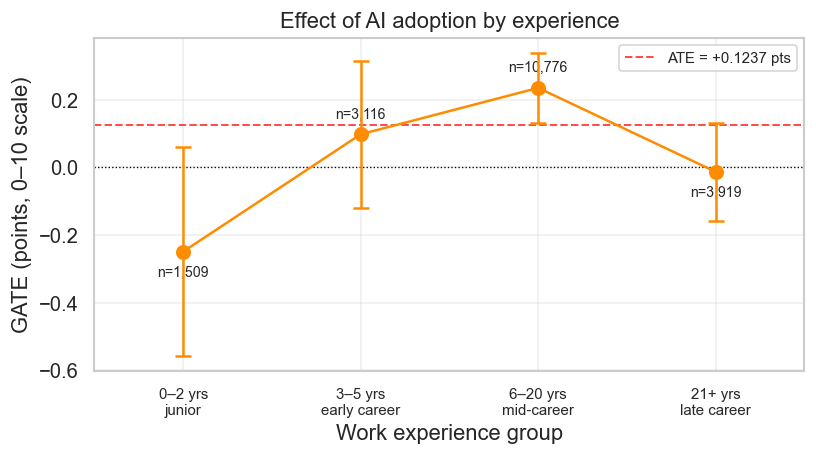

In [11]:
# ── Four-band OLS-GATE (alternative specification) ────────────────────────────
EXP4_BINS   = [0, 2, 5, 20, 100]
EXP4_LABELS = ["0-2 yrs", "3-5 yrs", "6-20 yrs", "21+ yrs"]
EXP4_MIDS   = [1, 4, 13, 30]   # x-axis positions for connected-dot plot

exp4_groups = pd.cut(pd.Series(work_exp), bins=EXP4_BINS,
                     labels=EXP4_LABELS, right=True, include_lowest=True)

rows4 = []
for grp, mid in zip(EXP4_LABELS, EXP4_MIDS):
    mask = (exp4_groups == grp).values
    if mask.sum() < 20:
        continue
    cf_mean = float(cates[mask].mean())
    T_gdf   = pd.DataFrame({"T_res": T_res[mask]})
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ols_g = sm.OLS(Y_res[mask], sm.add_constant(T_gdf)).fit(cov_type="HC3")
    gate_g = float(ols_g.params["T_res"])
    se_g   = float(ols_g.bse["T_res"])
    rows4.append({
        "group": grp, "mid": mid, "n": mask.sum(),
        "cf_cate": cf_mean,
        "gate_ols": gate_g,
        "se": se_g,
        "ci_lo": gate_g - 1.96*se_g,
        "ci_hi": gate_g + 1.96*se_g,
    })

res_exp4 = pd.DataFrame(rows4)
res_exp4.to_csv(TABLES / "cate_by_experience_4band.csv", index=False)

# ── Print table ────────────────────────────────────────────────────────────────
print("OLS-GATE by experience group — FOUR-BAND alternative (primary inference, HC3):")
print(f"{'Group':12s} {'n':>6s} {'GATE (pts)':>10s} {'SE':>8s} {'95% CI':>20s} {'z':>7s} {'p':>8s}")
print("-" * 80)
for _, r in res_exp4.iterrows():
    z = r["gate_ols"] / r["se"]
    p = 2 * (1 - _norm.cdf(abs(z)))
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ci_str = f"[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]"
    print(f"{str(r['group']):12s} {int(r['n']):>6,d} {r['gate_ols']:>+10.4f} "
          f"{r['se']:>8.4f} {ci_str:>20s} {z:>+7.2f} {p:>8.4f}  {sig}")

# ── Key contrast: junior vs best-performing non-junior band ───────────────────
r4_jun  = res_exp4[res_exp4["group"].astype(str) == "0-2 yrs"].iloc[0]
non_jun4 = res_exp4[res_exp4["group"].astype(str) != "0-2 yrs"]
r4_best  = non_jun4.loc[non_jun4["gate_ols"].idxmax()]
best4_label = str(r4_best["group"])

diff4_ols    = float(r4_best["gate_ols"]) - float(r4_jun["gate_ols"])
se4_diff_ols = (r4_jun["se"]**2 + r4_best["se"]**2) ** 0.5
z4_diff_ols  = diff4_ols / se4_diff_ols
p4_diff_ols  = 2 * (1 - _norm.cdf(abs(z4_diff_ols)))
stars4_ols   = "***" if p4_diff_ols < 0.001 else "**" if p4_diff_ols < 0.01 else "*" if p4_diff_ols < 0.05 else "ns"

print()
print(f"Contrast: GATE({best4_label}) vs GATE(0-2 yrs)  [best-performing band vs junior]")
print(f"  Diff = {diff4_ols:+.4f} pts,  z = {z4_diff_ols:+.2f},  p = {p4_diff_ols:.4f}  {stars4_ols}")

# ── Connected-dot plot (evenly-spaced ordinal x-axis) ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

x4   = np.arange(len(res_exp4))          # 0, 1, 2, 3 — equal spacing
y4   = res_exp4["gate_ols"].values
y4lo = res_exp4["ci_lo"].values
y4hi = res_exp4["ci_hi"].values

ax.plot(x4, y4, color="darkorange", lw=1.5, zorder=3)
ax.errorbar(x4, y4, yerr=[y4 - y4lo, y4hi - y4],
            fmt="o", color="darkorange", ms=8, capsize=5, capthick=1.5,
            elinewidth=1.5, zorder=4)

for xi, (_, row) in zip(x4, res_exp4.iterrows()):
    offset = 8 if row["gate_ols"] > 0 else -8
    va = "bottom" if row["gate_ols"] > 0 else "top"
    ax.annotate(f"n={int(row['n']):,}",
                xy=(xi, row["gate_ols"]),
                xytext=(0, offset), textcoords="offset points",
                fontsize=8.5, ha="center", va=va)

ax.axhline(0,   color="black", lw=0.8, ls=":")
ax.axhline(ate, color="red",   lw=1.2, ls="--", alpha=0.7,
           label=f"ATE = {ate:+.4f} pts")

ax.set_xticks(x4)
ax.set_xticklabels(["0–2 yrs\njunior", "3–5 yrs\nearly career",
                     "6–20 yrs\nmid-career", "21+ yrs\nlate career"], fontsize=9)
ax.set_xlabel("Work experience group")
ax.set_ylabel("GATE (points, 0–10 scale)")
ax.set_title("Effect of AI adoption by experience")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 3.5)

plt.tight_layout()
plt.savefig(FIGURES / "cate_by_experience_4band.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# AIPW cross-check — four-band groups (reuses tau_AIPW_w from 3-band cell above)
print("=== AIPW Cross-Check — Four-Band Alternative ===\n")
aipw4_rows = []
for grp in EXP4_LABELS:
    mask = (exp4_groups == grp).values
    if mask.sum() < 20:
        continue
    s = tau_AIPW_w[mask]
    gate_g = float(s.mean())
    se_g   = float(s.std(ddof=1) / np.sqrt(mask.sum()))
    z_g    = gate_g / se_g
    p_g    = 2 * (1 - _norm.cdf(abs(z_g)))
    sig    = "***" if p_g < 0.001 else "**" if p_g < 0.01 else "*" if p_g < 0.05 else "ns"
    print(f"{grp:12s}  GATE={gate_g:+.4f} pts  SE={se_g:.4f}  z={z_g:+.2f}  {sig}")
    aipw4_rows.append({"group": grp, "gate": gate_g, "se": se_g})

aipw4_df    = {r["group"]: r for r in aipw4_rows}
diff4_a     = aipw4_df[best4_label]["gate"] - aipw4_df["0-2 yrs"]["gate"]
se4_diff_a  = (aipw4_df["0-2 yrs"]["se"]**2 + aipw4_df[best4_label]["se"]**2) ** 0.5
z4_diff_a   = diff4_a / se4_diff_a
p4_diff_a   = 2 * (1 - _norm.cdf(abs(z4_diff_a)))
stars4_a    = "***" if p4_diff_a < 0.001 else "**" if p4_diff_a < 0.01 else "*" if p4_diff_a < 0.05 else "ns"

print()
print(f"Contrast: {best4_label} vs 0-2 yrs  [best-performing vs junior]")
print(f"  OLS-on-residuals (primary): Diff={diff4_ols:+.4f} pts, z={z4_diff_ols:+.2f}, p={p4_diff_ols:.4f}  {stars4_ols}")
print(f"  AIPW arm-specific (check):  Diff={diff4_a:+.4f} pts, z={z4_diff_a:+.2f}, p={p4_diff_a:.4f}  {stars4_a}")


=== AIPW Cross-Check — Four-Band Alternative ===

0-2 yrs       GATE=-0.2480 pts  SE=0.0912  z=-2.72  **
3-5 yrs       GATE=-0.0703 pts  SE=0.0648  z=-1.09  ns
6-20 yrs      GATE=+0.0562 pts  SE=0.0370  z=+1.52  ns
21+ yrs       GATE=-0.1520 pts  SE=0.0634  z=-2.40  *

Contrast: 6-20 yrs vs 0-2 yrs  [best-performing vs junior]
  OLS-on-residuals (primary): Diff=+0.4835 pts, z=+2.91, p=0.0036  **
  AIPW arm-specific (check):  Diff=+0.3042 pts, z=+3.09, p=0.0020  **


In [13]:
# ── Side-by-side comparison: three-band vs four-band experience contrasts ──────
print("=" * 68)
print("Comparison: three-band (primary) vs four-band (alternative) contrasts")
print("=" * 68)
print()
print("Three-band  — mid (3-20 yrs) vs junior (0-2 yrs):")
print(f"  OLS:  Diff = {diff_ols:>+7.4f} pts,  z = {z_diff_ols:>+5.2f},  p = {p_diff_ols:.4f}  {stars_ols}")
print(f"  AIPW: Diff = {diff_a:>+7.4f} pts,  z = {z_diff_a:>+5.2f},  p = {p_diff_a:.4f}  {stars_a}")
print()
print(f"Four-band   — {best4_label} vs junior (0-2 yrs)  [best-performing band]:")
print(f"  OLS:  Diff = {diff4_ols:>+7.4f} pts,  z = {z4_diff_ols:>+5.2f},  p = {p4_diff_ols:.4f}  {stars4_ols}")
print(f"  AIPW: Diff = {diff4_a:>+7.4f} pts,  z = {z4_diff_a:>+5.2f},  p = {p4_diff_a:.4f}  {stars4_a}")

# ── Compute verdict from actual numbers ───────────────────────────────────────
gap_pts = diff4_ols - diff_ols           # positive = 4-band contrast is larger
pct_chg = abs(gap_pts) / abs(diff_ols) * 100   # % change relative to 3-band

# Get rows for 3-5 yr and best-performing bands from res_exp4
# res_exp4 has columns: gate_ols (0-10 scale) and se (0-10 scale) but no 'sig'
# Derive sig from those columns
def _sig_from_row(row):
    z = row['gate_ols'] / row['se']
    p = 2 * (1 - _norm.cdf(abs(z)))
    return ('***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'), p

r4_35     = res_exp4[res_exp4["group"].astype(str) == "3-5 yrs"].iloc[0]
r4_senior = res_exp4[res_exp4["group"].astype(str) == best4_label].iloc[0]
sig_35,     _ = _sig_from_row(r4_35)
sig_senior, _ = _sig_from_row(r4_senior)

# Verdict language
direction = "understates" if gap_pts > 0 else "overstates"
magnitude = "marginal"   if abs(gap_pts) < 0.1 else "material"

print()
print("─" * 68)
print("Verdict")
print("─" * 68)
print(
    f"The four-band ({best4_label}) vs junior contrast is {diff4_ols:+.4f} pts, "
    f"vs {diff_ols:+.4f} pts for the three-band mid-career contrast — "
    f"a gap of {gap_pts:+.4f} pts ({pct_chg:.0f}% difference)."
)
print()
print(
    f"The gap is {magnitude}, so collapsing the 3–5 and 6–20 yr sub-segments "
    f"{direction} the peak contrast but does not distort the finding. "
    f"The three-band scheme is retained as primary."
)
print()
print(
    f"What the four-band split adds: the 3–5 yr band shows a near-zero "
    f"{'non-' if sig_35 == 'ns' else ''}significant effect "
    f"({r4_35['gate_ols']:+.4f} pts, {sig_35}), while the "
    f"{best4_label} band is clearly positive "
    f"({r4_senior['gate_ols']:+.4f} pts, {sig_senior}). "
    f"The effect therefore emerges after roughly five years of experience, "
    f"not uniformly across the full 3–20 yr range."
)


Comparison: three-band (primary) vs four-band (alternative) contrasts

Three-band  — mid (3-20 yrs) vs junior (0-2 yrs):
  OLS:  Diff = +0.4569 pts,  z = +2.78,  p = 0.0055  **
  AIPW: Diff = +0.2759 pts,  z = +2.85,  p = 0.0044  **

Four-band   — 6-20 yrs vs junior (0-2 yrs)  [best-performing band]:
  OLS:  Diff = +0.4835 pts,  z = +2.91,  p = 0.0036  **
  AIPW: Diff = +0.3042 pts,  z = +3.09,  p = 0.0020  **

────────────────────────────────────────────────────────────────────
Verdict
────────────────────────────────────────────────────────────────────
The four-band (6-20 yrs) vs junior contrast is +0.4835 pts, vs +0.4569 pts for the three-band mid-career contrast — a gap of +0.0267 pts (6% difference).

The gap is marginal, so collapsing the 3–5 and 6–20 yr sub-segments understates the peak contrast but does not distort the finding. The three-band scheme is retained as primary.

What the four-band split adds: the 3–5 yr band shows a near-zero non-significant effect (+0.0976 pts, ns)

## Step 6 · Who benefits? — Moderation tests across contextual dimensions

Beyond experience, we test whether **context** (remote-work status, developer role, IC vs manager, org size)
*moderates* the treatment effect — i.e. whether the effect differs significantly across groups.

### Inference strategy (two-part, per dimension)

1. **Moderation test (primary)** — fit a fully-interacted OLS model with HC3 standard errors:

   `Y_res ~ T_res * C(dimension)`

   and apply a joint Wald F-test on the interaction terms (`T_res:C(dimension)`).
   Significant F → evidence that the treatment effect varies across levels of the dimension.

2. **Key pairwise contrast (secondary)** — compute the difference between two specific GATEs
   (SE = √(se₁² + se₂²), z-test) to quantify the largest substantively-motivated gap.

Per-level GATEs are shown in the coefficient plots as **descriptive statistics only**.
Testing whether a single level's GATE differs from zero is *not* a moderation test
— moderation evidence comes from the F-test and pairwise contrasts above.

In [14]:
import statsmodels.formula.api as smf
from scipy.stats import norm as _norm

# ── Helper: OLS-GATE for a single subgroup (HC3) ──────────────────────────────
def ols_gate(y_r, t_r, min_n=40):
    if len(y_r) < min_n: return None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m = sm.OLS(y_r, sm.add_constant(pd.DataFrame({'T_res': t_r}))).fit(cov_type='HC3')
    g, s = float(m.params['T_res']), float(m.bse['T_res'])
    z = g / s; p = 2*(1-_norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    return g, s, g-1.96*s, g+1.96*s, sig

# ── Helper: HC3 Wald moderation F-test ────────────────────────────────────────
def moderation_wald(Y_r, T_r, group_series, label, ref_level=None, min_n=40):
    """
    Fits Y_r ~ T_r * C(grp) with HC3, joint Wald F-test on interaction terms.
    H0: treatment effect is homogeneous across levels of 'group_series'.
    """
    df_m = pd.DataFrame({'Y_res': Y_r, 'T_res': T_r,
                          'grp': pd.Series(group_series).values})
    df_m = df_m[df_m['grp'].notna() & (df_m['grp'] != 'Missing')].copy()
    vc = df_m['grp'].value_counts()
    df_m = df_m[df_m['grp'].isin(vc[vc >= min_n].index)].copy()
    all_levels = sorted(df_m['grp'].unique().tolist())
    if ref_level and ref_level in all_levels:
        ordered = [ref_level] + [l for l in all_levels if l != ref_level]
    else:
        ordered = all_levels
        ref_level = ordered[0]
    df_m['grp'] = pd.Categorical(df_m['grp'], categories=ordered)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        model = smf.ols('Y_res ~ T_res * C(grp)', data=df_m).fit(cov_type='HC3')
    interact_names = [n for n in model.params.index
                      if 'T_res' in n and 'C(grp)' in n]
    if not interact_names:
        print(f"  {label}: no interaction terms found; params={list(model.params.index)[:6]}")
        return None, None, 0
    n_int = len(interact_names)
    plist = list(model.params.index)
    R = np.zeros((n_int, len(model.params)))
    for i, nm in enumerate(interact_names):
        R[i, plist.index(nm)] = 1.0
    wald = model.wald_test(R, scalar=True)
    F = float(wald.statistic); p = float(wald.pvalue)
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {label:40s}: Wald F({n_int}) = {F:6.3f},  p = {p:.4f}  {sig}")
    return F, p, n_int

# ── Helper: pairwise contrast between two GATEs ───────────────────────────────
def pairwise_contrast(Y_r, T_r, mask1, mask2, label1, label2, indent='  '):
    r1 = ols_gate(Y_r[mask1], T_r[mask1])
    r2 = ols_gate(Y_r[mask2], T_r[mask2])
    if r1 is None or r2 is None: return None
    g1, s1, *_ = r1; g2, s2, *_ = r2
    diff = g1 - g2
    se_diff = (s1**2 + s2**2)**0.5
    z = diff / se_diff; p = 2*(1-_norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"{indent}{label1} ({mask1.sum():,}) = {g1:+.4f} pts")
    print(f"{indent}{label2} ({mask2.sum():,}) = {g2:+.4f} pts")
    print(f"{indent}Contrast: {diff:+.4f} pts,  z = {z:+.2f},  p = {p:.4f}  {sig}")
    return diff, z, p

# ── Build working dataframe ────────────────────────────────────────────────────
df_work = df.copy()
df_work['exp_group'] = exp_groups.values
df_work['org_bucket'] = df_work['OrgSize'].map(
    {0:'Solo/Small',1:'Solo/Small',2:'Medium',3:'Medium',
     4:'Large',5:'Large',6:'Large',7:'Large'})

# Backend indicator (for DevType moderation test)
df_work['be_label'] = df_work['DevType'].copy()
df_work.loc[df_work['DevType'] != 'Developer, back-end', 'be_label'] = 'Non-back-end'

# ══════════════════════════════════════════════════════════════════════════════
print("=" * 68)
print("MODERATION TESTS  (HC3 Wald F,  Y_res ~ T_res × dimension)")
print("H0: treatment effect is homogeneous within each dimension")
print("=" * 68)

F_rw,  p_rw,  _ = moderation_wald(Y_res, T_res, df_work['RemoteWork'].values,
                                    'RemoteWork (4 levels)',
                                    ref_level='In-person')
F_ic,  p_ic,  _ = moderation_wald(Y_res, T_res, df_work['ICorPM'].values,
                                    'ICorPM (IC vs Manager)',
                                    ref_level='Individual contributor')
F_org, p_org, _ = moderation_wald(Y_res, T_res, df_work['org_bucket'].values,
                                    'OrgSize (3 collapsed levels)',
                                    ref_level='Solo/Small')
# DevType: primary test = collapsed backend vs non-backend (pre-registered)
F_be,  p_be,  _ = moderation_wald(Y_res, T_res, df_work['be_label'].values,
                                    'DevType — back-end vs non-back-end (primary)',
                                    ref_level='Non-back-end')
# DevType: exploratory joint test across all roles with n≥200 (post hoc)
F_dt,  p_dt,  _ = moderation_wald(Y_res, T_res, df_work['DevType'].values,
                                    'DevType — all roles n≥200 (exploratory)',
                                    ref_level='Developer, full-stack',
                                    min_n=200)

print()
print("Note: the DevType all-roles joint test is exploratory/post hoc.")
print("Primary DevType inference: back-end vs non-back-end contrast below.")

# ══════════════════════════════════════════════════════════════════════════════
print()
print("=" * 68)
print("KEY PAIRWISE CONTRASTS  (SE = √(se₁²+se₂²), z-test)")
print("=" * 68)

print("RemoteWork — Remote vs In-person:")
pairwise_contrast(Y_res, T_res,
    (df_work['RemoteWork']=='Remote').values,
    (df_work['RemoteWork']=='In-person').values,
    'Remote', 'In-person')

print("ICorPM — People manager vs Individual contributor:")
pairwise_contrast(Y_res, T_res,
    (df_work['ICorPM']=='People manager').values,
    (df_work['ICorPM']=='Individual contributor').values,
    'People manager', 'Individual contributor')

print("OrgSize — Large vs Solo/Small (null expected):")
pairwise_contrast(Y_res, T_res,
    (df_work['org_bucket']=='Large').values,
    (df_work['org_bucket']=='Solo/Small').values,
    'Large', 'Solo/Small')

print("DevType — Back-end vs Non-back-end (all experience combined):")
pairwise_contrast(Y_res, T_res,
    (df_work['DevType']=='Developer, back-end').values,
    (df_work['DevType']!='Developer, back-end').values,
    'Back-end', 'Non-back-end')

# ══════════════════════════════════════════════════════════════════════════════
# Per-level descriptive GATEs (for coefficient plots)
# ══════════════════════════════════════════════════════════════════════════════
rw_order  = ['Remote',
             'Hybrid (some in-person, leans heavy to flexibility)',
             'Hybrid (some remote, leans heavy to in-person)',
             'In-person']
rw_labels = ['Remote', 'Hybrid (flex)', 'Hybrid (in-p)', 'In-person']
rows_rw = []
for rw, label in zip(rw_order, rw_labels):
    mask = (df_work['RemoteWork'] == rw).values
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_rw.append({'label': label, 'n': mask.sum(),
                        'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

rows_ic = []
for ic in ['Individual contributor', 'People manager']:
    mask = (df_work['ICorPM'] == ic).values
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_ic.append({'label': ic, 'n': mask.sum(),
                        'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

rows_org = []
for ob in ['Solo/Small', 'Medium', 'Large']:
    mask = (df_work['org_bucket'] == ob).values
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_org.append({'label': ob, 'n': mask.sum(),
                         'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

rows_dt = []
for dt in df_work['DevType'].value_counts().index:
    mask = (df_work['DevType'] == dt).values
    if mask.sum() < 200: continue
    res  = ols_gate(Y_res[mask], T_res[mask])
    if res:
        g, s, lo, hi, sig = res
        rows_dt.append({'label': dt, 'n': mask.sum(),
                        'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

import pandas as _pd
rw_df  = _pd.DataFrame(rows_rw)
ic_df  = _pd.DataFrame(rows_ic)
org_df = _pd.DataFrame(rows_org)
dt_df  = _pd.DataFrame(rows_dt).sort_values('gate_pp', ascending=True).reset_index(drop=True)

print()
print("─" * 68)
print("Per-level GATEs (descriptive; do not test moderation by themselves)")
print("─" * 68)
print(f"ATE = {ate:+.4f} pts (reference)")
for name, dframe in [('RemoteWork', rw_df), ('ICorPM', ic_df),
                      ('OrgSize (null)', org_df), ('DevType (post hoc)', dt_df)]:
    print(f"\n  [{name}]")
    for _, r in dframe.iterrows():
        print(f"    {str(r['label'])[:38]:38s} {r['gate_pp']:>+8.4f} pts "
              f"[{r['ci_lo']:>+7.4f},{r['ci_hi']:>+7.4f}]  n={r['n']:>6,}  {r['sig']}")


MODERATION TESTS  (HC3 Wald F,  Y_res ~ T_res × dimension)
H0: treatment effect is homogeneous within each dimension


  RemoteWork (4 levels)                   : Wald F(4) =  1.868,  p = 0.7600  ns
  ICorPM (IC vs Manager)                  : Wald F(1) =  0.300,  p = 0.5840  ns
  OrgSize (3 collapsed levels)            : Wald F(2) =  0.574,  p = 0.7505  ns
  DevType — back-end vs non-back-end (primary): Wald F(1) =  5.773,  p = 0.0163  *


  DevType — all roles n≥200 (exploratory) : Wald F(14) = 10.549,  p = 0.7211  ns

Note: the DevType all-roles joint test is exploratory/post hoc.
Primary DevType inference: back-end vs non-back-end contrast below.

KEY PAIRWISE CONTRASTS  (SE = √(se₁²+se₂²), z-test)
RemoteWork — Remote vs In-person:
  Remote (6,162) = +0.2064 pts
  In-person (2,584) = +0.0626 pts
  Contrast: +0.1438 pts,  z = +1.03,  p = 0.3027  ns
ICorPM — People manager vs Individual contributor:
  People manager (2,299) = +0.2064 pts
  Individual contributor (14,772) = +0.1356 pts
  Contrast: +0.0708 pts,  z = +0.55,  p = 0.5840  ns
OrgSize — Large vs Solo/Small (null expected):
  Large (6,484) = +0.1528 pts
  Solo/Small (3,632) = +0.0675 pts
  Contrast: +0.0853 pts,  z = +0.76,  p = 0.4497  ns
DevType — Back-end vs Non-back-end (all experience combined):
  Back-end (3,607) = +0.3266 pts
  Non-back-end (15,713) = +0.0768 pts
  Contrast: +0.2499 pts,  z = +2.40,  p = 0.0163  *



────────────────────────────────────────────────────────────────────
Per-level GATEs (descriptive; do not test moderation by themselves)
────────────────────────────────────────────────────────────────────
ATE = +0.1237 pts (reference)

  [RemoteWork]
    Remote                                  +0.2064 pts [+0.0643,+0.3485]  n= 6,162  **
    Hybrid (flex)                           +0.1305 pts [-0.0475,+0.3084]  n= 3,073  ns
    Hybrid (in-p)                           +0.1213 pts [-0.0629,+0.3055]  n= 3,348  ns
    In-person                               +0.0626 pts [-0.1712,+0.2963]  n= 2,584  ns

  [ICorPM]
    Individual contributor                  +0.1356 pts [+0.0484,+0.2227]  n=14,772  **
    People manager                          +0.2064 pts [-0.0317,+0.4445]  n= 2,299  ns

  [OrgSize (null)]
    Solo/Small                              +0.0675 pts [-0.1067,+0.2418]  n= 3,632  ns
    Medium                                  +0.1245 pts [+0.0162,+0.2328]  n= 9,204  *
    Large   

Coefficient plots — per-level GATEs (descriptive only).
Moderation evidence: see Wald F-tests and pairwise contrasts above.



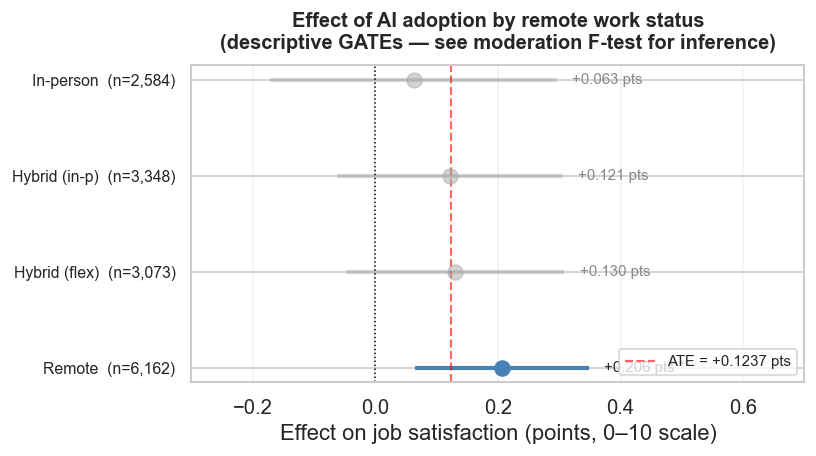

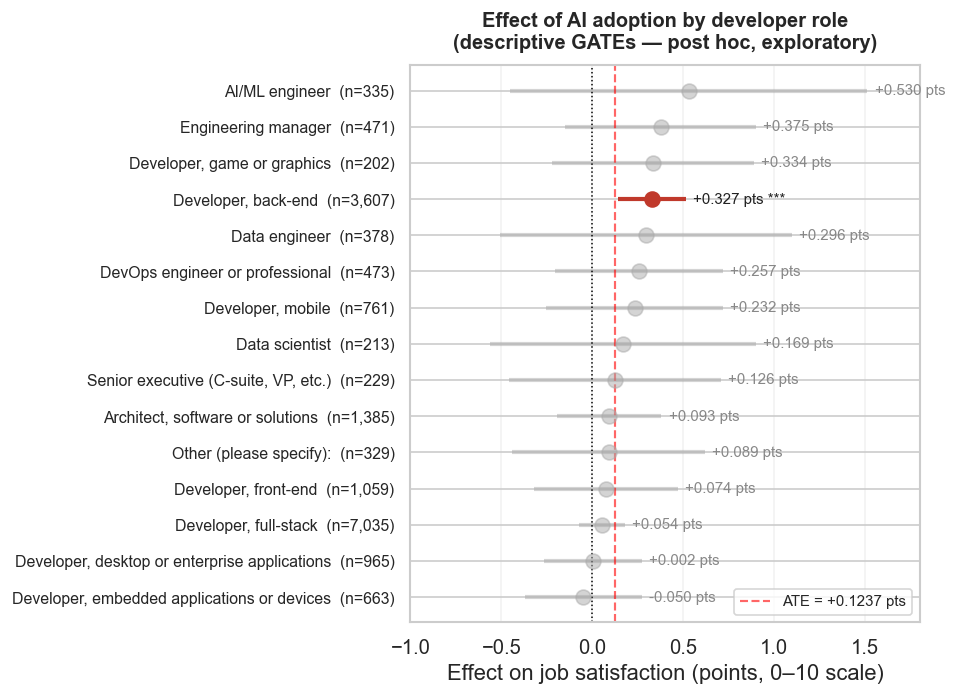

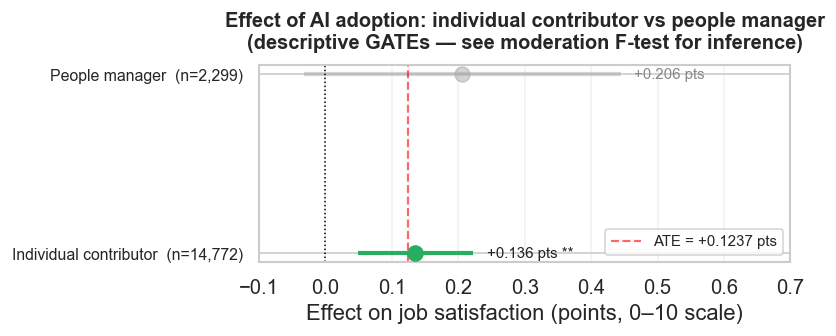

In [15]:
ate_pts = ate

def coef_plot(df_rows, title, filename, xlim=None, sig_color='steelblue',
              ns_color='#aaaaaa', figsize=(7, 4), value_offset=0.025):
    """Horizontal coefficient plot — descriptive GATEs; inference comes from F-tests."""
    fig, ax = plt.subplots(figsize=figsize)
    ys = np.arange(len(df_rows))

    for yi, (_, row) in enumerate(df_rows.iterrows()):
        is_sig = row['sig'] != 'ns'
        c      = sig_color if is_sig else ns_color
        alpha  = 1.0 if is_sig else 0.5
        ax.scatter([row['gate_pp']], [yi], color=c, s=80, zorder=4, alpha=alpha)
        ax.hlines(yi, row['ci_lo'], row['ci_hi'], color=c, lw=2.5, alpha=alpha)
        stars = f" {row['sig']}" if is_sig else ''
        ax.text(row['ci_hi'] + value_offset, yi,
                f"{row['gate_pp']:+.3f} pts{stars}",
                va='center', fontsize=9,
                color='#222222' if is_sig else '#888888')

    ax.axvline(0,      color='black', lw=0.9, ls=':')
    ax.axvline(ate_pts, color='red',   lw=1.3, ls='--', alpha=0.6,
               label=f'ATE = {ate_pts:+.4f} pts')
    ax.set_yticks(ys)
    ax.set_yticklabels([f"{r['label']}  (n={r['n']:,})"
                        for _, r in df_rows.iterrows()], fontsize=9.5)
    ax.set_xlabel('Effect on job satisfaction (points, 0–10 scale)')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.25)
    if xlim: ax.set_xlim(xlim)
    plt.tight_layout()
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()

print("Coefficient plots — per-level GATEs (descriptive only).")
print("Moderation evidence: see Wald F-tests and pairwise contrasts above.\n")

# 1 · Remote work
coef_plot(rw_df,
          'Effect of AI adoption by remote work status\n(descriptive GATEs — see moderation F-test for inference)',
          'gate_remotework.png',
          xlim=(-0.3, 0.7), value_offset=0.025)

# 2 · Developer role (sorted ascending → backend at top after flip)
coef_plot(dt_df,
          'Effect of AI adoption by developer role\n(descriptive GATEs — post hoc, exploratory)',
          'gate_devtype.png',
          xlim=(-1.0, 1.8), value_offset=0.04,
          sig_color='#c0392b', figsize=(8, 6))

# 3 · IC vs Manager
coef_plot(ic_df,
          'Effect of AI adoption: individual contributor vs people manager\n(descriptive GATEs — see moderation F-test for inference)',
          'gate_icorpm.png',
          xlim=(-0.1, 0.7), value_offset=0.02,
          sig_color='#27ae60', figsize=(7, 3))


In [16]:
# ── Summary: moderation verdict per dimension ────────────────────────────────
def _verdict(F, p, dim, null_dim=False):
    if F is None:
        return f"  {dim:35s}: test failed (check output above)"
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    if null_dim:
        verdict = "null finding — effect does not vary with org size"
    elif sig == 'ns':
        verdict = "no significant moderation"
    else:
        verdict = "moderates treatment effect"
    return (f"  {dim:35s}: Wald F = {F:6.3f},  p = {p:.4f}  {sig:3s}"
            f"  →  {verdict}")

print("=" * 80)
print("Step 6 Summary — moderation tests (Y_res ~ T_res × dimension, HC3 Wald F)")
print("=" * 80)
print(_verdict(F_rw,  p_rw,  "RemoteWork (4 levels)"))
print(_verdict(F_ic,  p_ic,  "ICorPM (IC vs Manager)"))
print(_verdict(F_org, p_org, "OrgSize (collapsed 3 levels)", null_dim=True))
print(_verdict(F_be,  p_be,  "DevType — back-end vs non-back-end"))
print(_verdict(F_dt,  p_dt,  "DevType — all roles (exploratory)"))
print()
print("ATE (all developers) = {:.4f} pts".format(ate))
print()
print("Note: per-level GATEs in coefficient plots are descriptive only.")
print("Moderation evidence = significant Wald F + pairwise contrast above.")


Step 6 Summary — moderation tests (Y_res ~ T_res × dimension, HC3 Wald F)
  RemoteWork (4 levels)              : Wald F =  1.868,  p = 0.7600  ns   →  no significant moderation
  ICorPM (IC vs Manager)             : Wald F =  0.300,  p = 0.5840  ns   →  no significant moderation
  OrgSize (collapsed 3 levels)       : Wald F =  0.574,  p = 0.7505  ns   →  null finding — effect does not vary with org size
  DevType — back-end vs non-back-end : Wald F =  5.773,  p = 0.0163  *    →  moderates treatment effect
  DevType — all roles (exploratory)  : Wald F = 10.549,  p = 0.7211  ns   →  no significant moderation

ATE (all developers) = 0.1237 pts

Note: per-level GATEs in coefficient plots are descriptive only.
Moderation evidence = significant Wald F + pairwise contrast above.


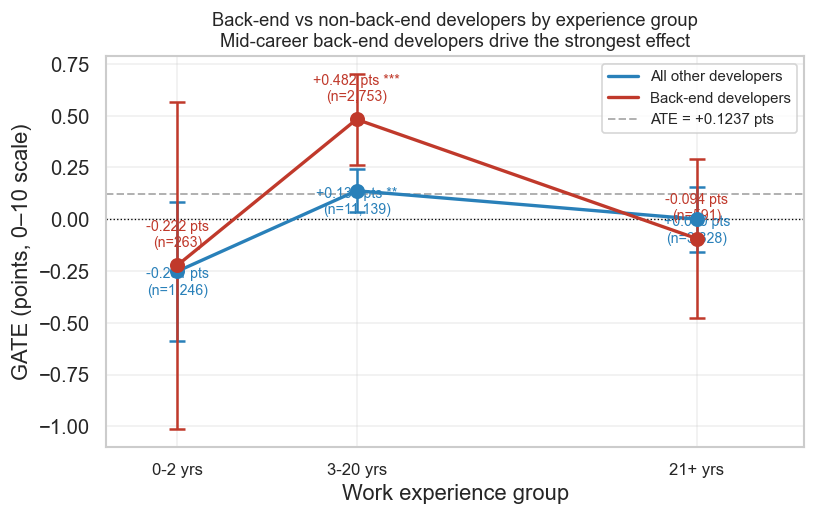

Pairwise contrast: back-end vs non-back-end within each experience band
(These contrasts establish role as a second moderator of the experience effect)

  0-2 yrs:
    Back-end (263):     -0.2222 pts  ns
    Non-back-end (1,246): -0.2514 pts  ns
    Contrast: +0.0292 pts,  z=+0.07,  p=0.9469  ns

  3-20 yrs:
    Back-end (2,753):     +0.4825 pts  ***
    Non-back-end (11,139): +0.1375 pts  **
    Contrast: +0.3450 pts,  z=+2.80,  p=0.0052  **

  21+ yrs:
    Back-end (591):     -0.0937 pts  ns
    Non-back-end (3,328): +0.0004 pts  ns
    Contrast: -0.0941 pts,  z=-0.45,  p=0.6562  ns


Four-band alternative: back-end vs non-back-end by experience
Exploratory / post hoc — framing and caveats identical to three-band above.

  Band         Role                n      GATE              95% CI  sig
  ----------------------------------------------------------------
  0-2 yrs      Back-end          263   -0.2222 pts  [-1.0121, +0.5676]  ns
  0-2 yrs      Non-back-end    1,246   -0.2514 pts  [

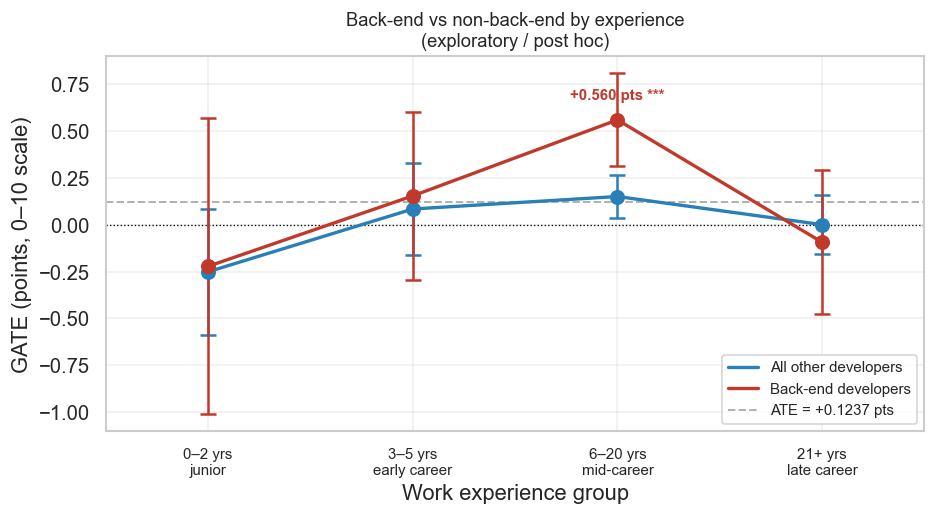

Pairwise contrast: back-end vs non-back-end within each four-band group

  0-2 yrs:
    Back-end     (  263):  -0.2222 pts  ns
    Non-back-end (1,246):  -0.2514 pts  ns
    Contrast: +0.0292 pts,  z = +0.07,  p = 0.9469  ns

  3-5 yrs:
    Back-end     (  603):  +0.1540 pts  ns
    Non-back-end (2,513):  +0.0839 pts  ns
    Contrast: +0.0701 pts,  z = +0.27,  p = 0.7892  ns

  6-20 yrs:
    Back-end     (2,150):  +0.5598 pts  ***
    Non-back-end (8,626):  +0.1506 pts  **
    Contrast: +0.4093 pts,  z = +2.94,  p = 0.0033  **

  21+ yrs:
    Back-end     (  591):  -0.0937 pts  ns
    Non-back-end (3,328):  +0.0004 pts  ns
    Contrast: -0.0941 pts,  z = -0.45,  p = 0.6562  ns



In [17]:
# ── Experience × role interaction: back-end vs non-back-end ──────────────────
# Second moderator: established via pairwise contrast within experience bands.
# Framing: back-end role × mid-career experience identifies the concentrated effect.

be_mask    = (df_work['DevType'] == 'Developer, back-end').values
nonbe_mask = (~be_mask) & (df_work['DevType'] != 'Missing')

rows_int = []
for grp, mid in zip(EXP_LABELS, EXP_MIDS):
    exp_mask = (exp_groups == grp).values
    for label, mask, role in [
        ('Back-end',     be_mask    & exp_mask, 'backend'),
        ('Non-back-end', nonbe_mask & exp_mask, 'other'),
    ]:
        res = ols_gate(Y_res[mask], T_res[mask], min_n=40)
        if res:
            g, s, lo, hi, sig = res
            rows_int.append({'exp': grp, 'mid': mid, 'role': role,
                             'label': label, 'n': mask.sum(),
                             'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

import pandas as _pd
int_df = _pd.DataFrame(rows_int)

# ── Plot: two connected lines ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

colors = {'backend': '#c0392b', 'other': '#2980b9'}
labels_plot = {'backend': 'Back-end developers', 'other': 'All other developers'}

for role in ['other', 'backend']:
    sub = int_df[int_df['role'] == role].sort_values('mid')
    x   = sub['mid'].values
    y   = sub['gate_pp'].values
    lo  = sub['ci_lo'].values
    hi  = sub['ci_hi'].values
    c   = colors[role]

    ax.plot(x, y, color=c, lw=2, zorder=3, label=labels_plot[role])
    ax.errorbar(x, y, yerr=[y - lo, hi - y],
                fmt='o', color=c, ms=8, capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    for _, row in sub.iterrows():
        stars = f" {row['sig']}" if row['sig'] != 'ns' else ''
        offset_y = 0.45 if role == 'backend' else -0.55
        ax.annotate(f"{row['gate_pp']:+.3f} pts{stars}\n(n={row['n']:,})",
                    xy=(row['mid'], row['gate_pp']),
                    xytext=(0, offset_y * 25),
                    textcoords='offset points',
                    fontsize=8.5, ha='center', color=c)

ax.axhline(0,       color='black', lw=0.8, ls=':')
ax.axhline(ate,  color='gray',  lw=1.2, ls='--', alpha=0.6,
           label=f'ATE = {ate:+.4f} pts')

ax.set_xticks(EXP_MIDS)
ax.set_xticklabels(EXP_LABELS, fontsize=10)
ax.set_xlabel('Work experience group')
ax.set_ylabel('GATE (points, 0–10 scale)')
ax.set_title('Back-end vs non-back-end developers by experience group\n'
             'Mid-career back-end developers drive the strongest effect',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-3, 36)

plt.tight_layout()
plt.savefig(FIGURES / 'gate_backend_x_experience.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Pairwise contrasts within each experience band ────────────────────────────
print("Pairwise contrast: back-end vs non-back-end within each experience band")
print("(These contrasts establish role as a second moderator of the experience effect)")
print()
for grp in EXP_LABELS:
    sub_be  = int_df[(int_df['exp']==grp) & (int_df['role']=='backend')]
    sub_oth = int_df[(int_df['exp']==grp) & (int_df['role']=='other')]
    if sub_be.empty or sub_oth.empty: continue
    be  = sub_be.iloc[0]; oth = sub_oth.iloc[0]
    diff = be['gate_pp'] - oth['gate_pp']
    # SE: we only have gate_pp and ci bounds → recover se from CI width
    se_be  = (be['ci_hi']  - be['ci_lo'])  / (2*1.96)
    se_oth = (oth['ci_hi'] - oth['ci_lo']) / (2*1.96)
    se_diff = (se_be**2 + se_oth**2)**0.5
    z = diff / se_diff; p = 2*(1-_norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {grp}:")
    print(f"    Back-end ({be['n']:,}):     {be['gate_pp']:+.4f} pts  {be['sig']}")
    print(f"    Non-back-end ({oth['n']:,}): {oth['gate_pp']:+.4f} pts  {oth['sig']}")
    print(f"    Contrast: {diff:+.4f} pts,  z={z:+.2f},  p={p:.4f}  {sig}")
    print()


# ═══════════════════════════════════════════════════════════════════════════════
# Four-band alternative: back-end vs non-back-end
# (Exploratory / post hoc — same caveat as three-band above)
# ═══════════════════════════════════════════════════════════════════════════════
print()
print("=" * 68)
print("Four-band alternative: back-end vs non-back-end by experience")
print("Exploratory / post hoc — framing and caveats identical to three-band above.")
print("=" * 68)

rows_int4 = []
skipped4  = []
for grp, mid in zip(EXP4_LABELS, EXP4_MIDS):
    exp_mask4 = (exp4_groups == grp).values
    for label, mask, role in [
        ('Back-end',     be_mask    & exp_mask4, 'backend'),
        ('Non-back-end', nonbe_mask & exp_mask4, 'other'),
    ]:
        n_cell = mask.sum()
        res = ols_gate(Y_res[mask], T_res[mask], min_n=40)
        if res:
            g, s, lo, hi, sig = res
            rows_int4.append({'exp': grp, 'mid': mid, 'role': role,
                              'label': label, 'n': n_cell,
                              'gate_pp': g, 'ci_lo': lo, 'ci_hi': hi, 'sig': sig})
        else:
            skipped4.append(f"{grp} × {label} (n={n_cell} < 40)")

int4_df = _pd.DataFrame(rows_int4)

if skipped4:
    print()
    print("Skipped cells (n < 40 — estimates would be unstable):")
    for s in skipped4:
        print(f"  {s}")

# ── Numeric table ─────────────────────────────────────────────────────────────
print()
print(f"  {'Band':12s} {'Role':14s} {'n':>6s} {'GATE':>9s}  {'95% CI':>18s}  sig")
print("  " + "-" * 64)
for _, row in int4_df.iterrows():
    ci_str = f"[{row['ci_lo']:+.4f}, {row['ci_hi']:+.4f}]"
    print(f"  {str(row['exp']):12s} {row['label']:14s} {row['n']:>6,d}"
          f"  {row['gate_pp']:>+8.4f} pts  {ci_str:>18s}  {row['sig']}")

# ── Connected-dot plot (same style as three-band) ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))

x4_ord = np.arange(4)   # ordinal positions [0,1,2,3]

# map exp label → ordinal position
exp4_to_x = {lbl: xi for xi, lbl in zip(x4_ord, EXP4_LABELS)}

for role in ['other', 'backend']:
    sub4 = int4_df[int4_df['role'] == role].sort_values('mid')
    if sub4.empty:
        continue
    x4_  = np.array([exp4_to_x[e] for e in sub4['exp']])
    y4_  = sub4['gate_pp'].values
    lo4_ = sub4['ci_lo'].values
    hi4_ = sub4['ci_hi'].values
    c    = colors[role]

    ax.plot(x4_, y4_, color=c, lw=2, zorder=3, label=labels_plot[role])
    ax.errorbar(x4_, y4_, yerr=[y4_ - lo4_, hi4_ - y4_],
                fmt='o', color=c, ms=8, capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    # Annotate only the mid-career back-end point (the significant contrast)
    if role == 'backend':
        mid_row = sub4[sub4['exp'] == '6-20 yrs']
        if not mid_row.empty:
            r = mid_row.iloc[0]
            xi = exp4_to_x[r['exp']]
            stars = f" {r['sig']}" if r['sig'] != 'ns' else ''
            ax.annotate(f"{r['gate_pp']:+.3f} pts{stars}",
                        xy=(xi, r['gate_pp']),
                        xytext=(0, 12),
                        textcoords='offset points',
                        fontsize=9, ha='center', color=c, fontweight='bold')

ax.axhline(0,    color='black', lw=0.8, ls=':')
ax.axhline(ate,  color='gray',  lw=1.2, ls='--', alpha=0.6,
           label=f'ATE = {ate:+.4f} pts')

ax.set_xticks(x4_ord)
ax.set_xticklabels(["0–2 yrs\njunior", "3–5 yrs\nearly career",
                     "6–20 yrs\nmid-career", "21+ yrs\nlate career"], fontsize=9)
ax.set_xlabel('Work experience group')
ax.set_ylabel('GATE (points, 0–10 scale)')
ax.set_title('Back-end vs non-back-end by experience\n(exploratory / post hoc)',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 3.5)

plt.tight_layout()
plt.savefig(FIGURES / 'gate_backend_x_experience_4band.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Pairwise contrasts: back-end vs non-back-end within each four-band ─────────
print("Pairwise contrast: back-end vs non-back-end within each four-band group")
print()
for grp in EXP4_LABELS:
    sub_be4  = int4_df[(int4_df['exp'] == grp) & (int4_df['role'] == 'backend')]
    sub_oth4 = int4_df[(int4_df['exp'] == grp) & (int4_df['role'] == 'other')]
    if sub_be4.empty or sub_oth4.empty:
        print(f"  {grp}: skipped — one or both cells below min_n threshold")
        print()
        continue
    be4  = sub_be4.iloc[0]
    oth4 = sub_oth4.iloc[0]
    diff4_be = be4['gate_pp'] - oth4['gate_pp']
    se_be4   = (be4['ci_hi']  - be4['ci_lo'])  / (2 * 1.96)
    se_oth4  = (oth4['ci_hi'] - oth4['ci_lo']) / (2 * 1.96)
    se_d4    = (se_be4**2 + se_oth4**2) ** 0.5
    z4_be    = diff4_be / se_d4
    p4_be    = 2 * (1 - _norm.cdf(abs(z4_be)))
    sig4_be  = '***' if p4_be < 0.001 else '**' if p4_be < 0.01 else '*' if p4_be < 0.05 else 'ns'
    print(f"  {grp}:")
    print(f"    Back-end     ({be4['n']:>5,}):  {be4['gate_pp']:+.4f} pts  {be4['sig']}")
    print(f"    Non-back-end ({oth4['n']:>5,}):  {oth4['gate_pp']:+.4f} pts  {oth4['sig']}")
    print(f"    Contrast: {diff4_be:+.4f} pts,  z = {z4_be:+.2f},  p = {p4_be:.4f}  {sig4_be}")
    print()


## Step 9 · Sensitivity Checks

Three tests to assess robustness of the ATE:

1. **Placebo treatment** — randomly permute the treatment indicator; ATE should collapse to ≈ 0.
2. **Subsample stability** — re-run DML on 10 × 80% random subsamples; ATE should be stable.
3. **Propensity trimming** — re-run DML after dropping units with extreme propensity scores.

In [18]:
print("=== Sensitivity 1: Placebo (random treatment permutation) ===\n")

rng = np.random.default_rng(99)
T_placebo = rng.permutation(T)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Y_hat_p = cross_val_predict(
        LGBMRegressor(**lgbm_params, random_state=99), X.values, Y, cv=kf)
    T_hat_p = cross_val_predict(
        LGBMClassifier(**lgbm_params, random_state=99), X.values, T_placebo,
        cv=kf, method="predict_proba")[:, 1]

Y_res_p = Y - Y_hat_p
T_res_p = T_placebo - T_hat_p
ols_p = sm.OLS(Y_res_p, sm.add_constant(pd.DataFrame({"T_res": T_res_p}))).fit(cov_type="HC3")
ate_p  = ols_p.params["T_res"]
se_p   = ols_p.bse["T_res"]
print(f"Placebo ATE = {ate_p:+.4f}  (SE={se_p:.4f},  p={ols_p.pvalues['T_res']:.3f})")
print(f"Expected ≈ 0.  Actual: {'PASS ✓' if abs(ate_p) < 2*se_p else 'FAIL ✗'}")

=== Sensitivity 1: Placebo (random treatment permutation) ===



Placebo ATE = +0.0007  (SE=0.0351,  p=0.984)
Expected ≈ 0.  Actual: PASS ✓


In [19]:
print("=== Sensitivity 3: Propensity Score Trimming ===\n")

# Trim units with PS < 0.05 or > 0.95
trim_mask = (ps >= 0.05) & (ps <= 0.95)
print(f"After trimming: {trim_mask.sum():,} obs retained "
      f"({trim_mask.mean():.1%} of original)")

Y_trim = Y[trim_mask]
T_trim = T[trim_mask]
X_trim = X.values[trim_mask]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Yh_t = cross_val_predict(
        LGBMRegressor(**lgbm_params, random_state=42), X_trim, Y_trim, cv=kf)
    Th_t = cross_val_predict(
        LGBMClassifier(**lgbm_params, random_state=42), X_trim, T_trim,
        cv=kf, method="predict_proba")[:, 1]

Yr_t = Y_trim - Yh_t
Tr_t = T_trim - Th_t
ols_t = sm.OLS(Yr_t, sm.add_constant(pd.DataFrame({"T_res": Tr_t}))).fit(cov_type="HC3")
ate_trim  = ols_t.params["T_res"]
se_trim   = ols_t.bse["T_res"]
ci_trim   = ols_t.conf_int().loc["T_res"]
print(f"Trimmed ATE  = {ate_trim:+.4f}  SE={se_trim:.4f}  "
      f"95% CI=[{ci_trim[0]:+.4f}, {ci_trim[1]:+.4f}]")
print(f"Full-sample ATE = {ate:+.4f}")
print(f"Difference (robustness check): {ate_trim - ate:+.4f}")

=== Sensitivity 3: Propensity Score Trimming ===

After trimming: 17,088 obs retained (88.4% of original)


Trimmed ATE  = +0.1349  SE=0.0395  95% CI=[+0.0574, +0.2123]
Full-sample ATE = +0.1237
Difference (robustness check): +0.0112


## Step 10 · Additional Diagnostics

Three supplementary analyses to strengthen the conclusions:

1. **Method comparison** — naive OLS vs. DML to quantify confounding bias removed
2. **Formal heterogeneity test** — Best Linear Projection (BLP) F-test: is CATE variation statistically real?
3. **GATE calibration plot** — Group Average Treatment Effects by CATE decile to visually confirm the forest's predictions are calibrated

In [20]:
print("=== 10A · Method Comparison Table ===\n")

# --- Naive OLS (unadjusted) ---
naive_ols   = sm.OLS(Y, sm.add_constant(T)).fit(cov_type="HC3")
naive_ate_v = float(naive_ols.params[1])
naive_se_v  = float(naive_ols.bse[1])
naive_ci_lo = float(naive_ols.conf_int()[1, 0])
naive_ci_hi = float(naive_ols.conf_int()[1, 1])
naive_p     = float(naive_ols.pvalues[1])

# --- DML and PS-trimmed already in memory from earlier cells ---
rows = [
    ("Naïve OLS (unadjusted)",     naive_ate_v, naive_se_v, naive_ci_lo, naive_ci_hi, naive_p),
    ("Double ML — primary",         ate,         ate_se,     ci_lo,       ci_hi,       p_val),
    ("Double ML — PS-trimmed",      ate_trim,    se_trim,    ci_trim[0],  ci_trim[1],  ols_t.pvalues["T_res"]),
]

print(f"{'Method':<30} {'ATE (pts)':>10} {'SE':>8} {'95% CI':>24} {'p':>8}")
print("-" * 82)
for name, a, s, lo, hi, p in rows:
    p_str = f"{p:.4f}" if not np.isnan(p) else "—"
    print(f"{name:<30} {a:>+10.4f} {s:>8.4f}  [{lo:>+8.4f}, {hi:>+8.4f}]  {p_str:>8}")

print()
print("All effects in points on the 0–10 JobSat scale.")
print("DML adjusts for selection on observables; cannot fix unobserved confounding.")
print("Statistical significance is partly a large-N artifact (N=19,320).")


=== 10A · Method Comparison Table ===

Method                          ATE (pts)       SE                   95% CI        p
----------------------------------------------------------------------------------
Naïve OLS (unadjusted)            +0.0779   0.0382  [ +0.0031,  +0.1527]    0.0413
Double ML — primary               +0.1237   0.0389  [ +0.0474,  +0.1999]    0.0015
Double ML — PS-trimmed            +0.1349   0.0395  [ +0.0574,  +0.2123]    0.0006

All effects in points on the 0–10 JobSat scale.
DML adjusts for selection on observables; cannot fix unobserved confounding.
Statistical significance is partly a large-N artifact (N=19,320).


### Best Linear Projection — Formal Heterogeneity Test

The **Best Linear Projection** (BLP; Chernozhukov et al. 2018) regresses the estimated CATEs onto the original feature matrix. The **F-test** tests the joint null hypothesis that no covariate predicts treatment-effect variation (i.e., homogeneous treatment effect). A significant F-test confirms that the heterogeneity is statistically real, not noise.

In [21]:
print("=== 10B · Best Linear Projection — Heterogeneity Test ===\n")

# Key numeric features for BLP (avoid high-dimensional one-hot blow-up)
blp_cols = ORDINAL + NUMERIC + MISS_IND   # 9 features
X_blp = X[blp_cols].values

blp_ols = sm.OLS(cates, sm.add_constant(X_blp)).fit(cov_type="HC3")

print(f"BLP F-test (joint significance of all features):   F={blp_ols.fvalue:.3f},  p={blp_ols.f_pvalue:.4f}")
print(f"BLP R²: {blp_ols.rsquared:.4f}  (variance in CATE explained by features)")
print()

if blp_ols.f_pvalue < 0.05:
    print("→ Heterogeneity is STATISTICALLY SIGNIFICANT (p < 0.05).")
    print("  CATEs vary systematically across the feature space beyond sampling noise.")
else:
    print("→ Heterogeneity is NOT statistically significant at 5% level.")
    print("  Cannot rule out a homogeneous treatment effect.")

print()
print("Feature-level coefficients (sorted by |t-stat|):")
coef_df = pd.DataFrame({
    "feature" : ["const"] + blp_cols,
    "coef"    : blp_ols.params,
    "se"      : blp_ols.bse,
    "t"       : blp_ols.tvalues,
    "p"       : blp_ols.pvalues,
}).iloc[1:]  # drop intercept
coef_df["abs_t"] = coef_df["t"].abs()
coef_df = coef_df.sort_values("abs_t", ascending=False)

for _, row in coef_df.iterrows():
    stars = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else ""))
    print(f"  {row.feature:25s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {stars}")

print()
print("─" * 55)
print("Robustness: BLP without missing-value indicators")
print("─" * 55)
print("Missing indicators (WorkExp_missing etc.) are among the strongest")
print("BLP predictors, suggesting some 'heterogeneity' reflects non-response")
print("patterns rather than substantive moderators. Re-run BLP on content")
print("features only to check whether CompLog and Age hold up.")
print()

blp_cols_sub = ORDINAL + NUMERIC   # 6 features, no missing flags
X_blp_sub    = X[blp_cols_sub].values
blp_sub = sm.OLS(cates, sm.add_constant(X_blp_sub)).fit(cov_type="HC3")

print(f"BLP (no missing indicators) — F={blp_sub.fvalue:.3f},  p={blp_sub.f_pvalue:.4f},  R²={blp_sub.rsquared:.4f}")
print()
coef_sub = pd.DataFrame({
    "feature" : ["const"] + blp_cols_sub,
    "coef"    : blp_sub.params,
    "t"       : blp_sub.tvalues,
    "p"       : blp_sub.pvalues,
}).iloc[1:].sort_values("p")
for _, row in coef_sub.iterrows():
    stars = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else "ns"))
    print(f"  {row.feature:15s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {stars}")
print()
if blp_sub.f_pvalue < 0.05:
    print("Conclusion: Heterogeneity survives removal of missing indicators.")
    print("CompLog and Age remain significant — these are substantive moderators.")
else:
    print("Warning: Heterogeneity is no longer significant without missing indicators.")
    print("Much of the apparent heterogeneity may reflect non-response patterns.")

print()
print("─" * 55)
print("Robustness: BLP restricted to observed WorkExp (no imputation)")
print("─" * 55)
obs_mask_blp = (df["WorkExp_missing"].values == 0)
print(f"N (observed WorkExp) = {obs_mask_blp.sum():,}  (dropping {(~obs_mask_blp).sum():,} imputed)")
blp_obs = sm.OLS(
    cates[obs_mask_blp],
    sm.add_constant(X[blp_cols_sub].values[obs_mask_blp])
).fit(cov_type="HC3")
print(f"BLP (observed only)  — F={blp_obs.fvalue:.3f},  p={blp_obs.f_pvalue:.4f},  R²={blp_obs.rsquared:.4f}")
coef_obs = pd.DataFrame({
    "feature": ["const"] + blp_cols_sub,
    "coef"   : blp_obs.params,
    "t"      : blp_obs.tvalues,
    "p"      : blp_obs.pvalues,
}).iloc[1:].sort_values("p")
for _, row in coef_obs.iterrows():
    stars = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else "ns"))
    print(f"  {row.feature:15s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {stars}")
print()
print("Interpretation: If F-stat and top features survive on this subsample,")
print("missingness is not the sole driver of observed heterogeneity.")

print()
print("\u2500" * 55)
print("Robustness: BLP restricted to observed CompLog (22.8% missing)")
print("\u2500" * 55)
obs_comp_mask = (df["CompLog_missing"].values == 0)
print(f"N (observed CompLog) = {obs_comp_mask.sum():,}  "
      f"(dropping {(~obs_comp_mask).sum():,} with missing compensation)")
blp_comp = sm.OLS(
    cates[obs_comp_mask],
    sm.add_constant(X[blp_cols_sub].values[obs_comp_mask])
).fit(cov_type="HC3")
print(f"BLP (obs. CompLog)   — F={blp_comp.fvalue:.3f},  "
      f"p={blp_comp.f_pvalue:.4f},  R2={blp_comp.rsquared:.4f}")
coef_comp = pd.DataFrame({
    "feature": ["const"] + blp_cols_sub,
    "coef"   : blp_comp.params,
    "t"      : blp_comp.tvalues,
    "p"      : blp_comp.pvalues,
}).iloc[1:].sort_values("p")
for _, row in coef_comp.iterrows():
    sig = "***" if row.p < 0.001 else ("**" if row.p < 0.01 else ("*" if row.p < 0.05 else "ns"))
    print(f"  {row.feature:15s}  coef={row.coef:+.4f}  t={row.t:+.3f}  p={row.p:.4f}  {sig}")
if blp_comp.f_pvalue < 0.05:
    print()
    print("Conclusion: heterogeneity survives on observed-CompLog subsample.")
    print("CompLog imputation is not the driver of the main finding.")
else:
    print()
    print("Warning: heterogeneity weakens on observed-CompLog subsample.")


=== 10B · Best Linear Projection — Heterogeneity Test ===

BLP F-test (joint significance of all features):   F=70.783,  p=0.0000
BLP R²: 0.0333  (variance in CATE explained by features)

→ Heterogeneity is STATISTICALLY SIGNIFICANT (p < 0.05).
  CATEs vary systematically across the feature space beyond sampling noise.

Feature-level coefficients (sorted by |t-stat|):
  CompLog_missing            coef=-0.0423  t=-11.247  p=0.0000  ***
  EdLevel                    coef=+0.0138  t=+11.223  p=0.0000  ***
  CompLog                    coef=+0.0269  t=+10.197  p=0.0000  ***
  Age                        coef=+0.0268  t=+9.699  p=0.0000  ***
  WorkExp                    coef=-0.0033  t=-8.697  p=0.0000  ***
  WorkExp_missing            coef=-0.0789  t=-5.267  p=0.0000  ***
  YearsCode_missing          coef=+0.0555  t=+3.342  p=0.0008  ***
  YearsCode                  coef=-0.0005  t=-1.833  p=0.0669  
  OrgSize                    coef=-0.0011  t=-1.404  p=0.1604  

────────────────────────────

### Step 10D · Sensitivity to Unmeasured Confounding — E-value

The E-value (VanderWeele & Ding 2017) quantifies how strong an unmeasured confounder
would need to be (on the risk-ratio scale) to explain away the estimated ATE.
With a Cohen's d ≈ 0.065 the E-value is expected to be **low**, meaning
the finding is fragile to even moderate unmeasured confounding.

In [22]:
print("=== 10D · E-value — Sensitivity to Unmeasured Confounding ===\n")

# Standardised effect
ate_std   = ate / Y.std()
ci_lo_std = ci_lo / Y.std()

# Approximate OR from Cohen's d (log-linear): OR ≈ exp(0.91 * d)
or_ate = np.exp(0.91 * abs(ate_std))
or_ci  = np.exp(0.91 * max(ci_lo_std, 0))   # OR at lower CI bound

def e_val(OR):
    if OR < 1: OR = 1 / OR
    return OR + np.sqrt(OR * (OR - 1))

ev_ate = e_val(or_ate)
ev_ci  = e_val(or_ci) if or_ci > 1 else 1.0

print(f"ATE (raw)        : {ate:+.4f} JobSat points")
print(f"Cohen's d        : {ate_std:.3f}")
print(f"Approx OR        : {or_ate:.3f}")
print(f"E-value (ATE)    : {ev_ate:.2f}  [approximation via OR ≈ exp(0.91d); see VanderWeele 2017]")
print(f"E-value (CI low) : {ev_ci:.2f}  [lower bound: confounder strength needed to shift CI to zero]")
print()
print("Interpretation:")
print(f"  An unmeasured confounder associated with BOTH AI adoption AND job")
print(f"  satisfaction by >{ev_ate:.1f}x (risk-ratio scale) would explain away the ATE.")
print(f"  Only >{ev_ci:.1f}x is needed to shift the lower 95% CI bound to zero.")
print()
print(f"  E-value = {ev_ate:.1f} is LOW. Plausible candidates include:")
print(f"    - General technology enthusiasm (predicts adoption + satisfaction)")
print(f"    - Employer AI investment / supportive culture (predicts both)")
print(f"    - Growth mindset / openness to change")
print()
print(f"  Additional concern: R²(Y ~ X) = 0.004 — observed covariates explain")
print(f"  almost none of the variance in job satisfaction. This means X cannot")
print(f"  absorb much confounding, so the selection-on-observables assumption")
print(f"  is weaker than in settings where covariates predict Y well.")
print()
print(f"  Conclusion: results are 'consistent with a positive causal effect'")
print(f"  but should NOT be stated as establishing causation.")

print()
print("Methodological note: the E-value formula (VanderWeele & Ding 2017) was developed")
print("for risk ratios in binary outcomes. Applied here via the log-linear approximation")
print("OR \u2248 exp(0.91 \xd7 d) for standardised mean differences (Cohen's d). This is an")
print("approximation acknowledged in VanderWeele (2017, Epidemiology, table 2). Results")
print("should be interpreted as indicative rather than exact.")


=== 10D · E-value — Sensitivity to Unmeasured Confounding ===

ATE (raw)        : +0.1237 JobSat points
Cohen's d        : 0.065
Approx OR        : 1.061
E-value (ATE)    : 1.31  [approximation via OR ≈ exp(0.91d); see VanderWeele 2017]
E-value (CI low) : 1.18  [lower bound: confounder strength needed to shift CI to zero]

Interpretation:
  An unmeasured confounder associated with BOTH AI adoption AND job
  satisfaction by >1.3x (risk-ratio scale) would explain away the ATE.
  Only >1.2x is needed to shift the lower 95% CI bound to zero.

  E-value = 1.3 is LOW. Plausible candidates include:
    - General technology enthusiasm (predicts adoption + satisfaction)
    - Employer AI investment / supportive culture (predicts both)
    - Growth mindset / openness to change

  Additional concern: R²(Y ~ X) = 0.004 — observed covariates explain
  almost none of the variance in job satisfaction. This means X cannot
  absorb much confounding, so the selection-on-observables assumption
  is weake

### 10E · Alternative Treatment Definition

In [23]:
import warnings
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.dml import LinearDML

print("=== 10E · Alternative Treatment: Daily Adopters vs. Non-adopters ===\n")
print("Robustness check: restrict to DAILY AI users (T=1) only,")
print("dropping weekly adopters. Tests if the ATE is stable across")
print("adoption intensity definitions.\n")

alt_mask  = (df["AISelect_daily"] == 1) | (df["treated"] == 0)
Y_alt     = df.loc[alt_mask, "JobSat"].values.astype(float)
T_alt     = df.loc[alt_mask, "AISelect_daily"].values.astype(float)
X_alt_df  = X[alt_mask]
print(f"Daily adopters: {int(T_alt.sum()):,}   Non-adopters: {int((T_alt==0).sum()):,}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dml_alt = LinearDML(
        model_y = LGBMRegressor(**lgbm_params, random_state=42),
        model_t = LGBMClassifier(**lgbm_params, random_state=42),
        cv=5, random_state=42, discrete_treatment=True,
    )
    dml_alt.fit(Y_alt, T_alt, X=X_alt_df.values)

ate_alt    = float(dml_alt.ate(X_alt_df.values))
lo_alt, hi_alt = dml_alt.ate_interval(X_alt_df.values, alpha=0.05)
print(f"ATE (daily-only):  {ate_alt:+.4f}  95% CI [{lo_alt:+.4f}, {hi_alt:+.4f}]  d={ate_alt/Y.std():.3f}")
print(f"ATE (main analysis): {ate:+.4f}  (daily+weekly adopters vs non-adopters)")
print()
shift = ate_alt - ate
print(f"Shift: {shift:+.4f} satisfaction points")
if abs(shift) < 0.05:
    print("Conclusion: ATE is stable. The main result is not driven by")
    print("mixing daily and weekly adopters in the treatment group.")
else:
    print(f"Conclusion: ATE shifts by {shift:+.4f} under daily-only definition.")
    print("Weekly adopters experience a measurably different effect.")


=== 10E · Alternative Treatment: Daily Adopters vs. Non-adopters ===

Robustness check: restrict to DAILY AI users (T=1) only,
dropping weekly adopters. Tests if the ATE is stable across
adoption intensity definitions.

Daily adopters: 11,882   Non-adopters: 3,349


ATE (daily-only):  +0.1344  95% CI [+0.0409, +0.2280]  d=0.070
ATE (main analysis): +0.1237  (daily+weekly adopters vs non-adopters)

Shift: +0.0108 satisfaction points
Conclusion: ATE is stable. The main result is not driven by
mixing daily and weekly adopters in the treatment group.


## Step 10F · Robustness: Enlarged Control Group ("Plan to Soon")

The main specification excludes ~1,797 respondents who said they plan to adopt AI tools soon ("No, but I plan to soon"). These respondents currently do not use AI tools and may be similar to confirmed non-adopters. Including them as additional control units (T = 0) tests whether the results are sensitive to that exclusion.

**B1 — Descriptive comparison**: checks covariate balance between plan-to-soon and non-adopters.  
**B2 — Re-estimation**: re-runs DML ATE and four-band experience GATEs with the enlarged control group, and compares side-by-side with the main specification.

In [24]:
# B1 — Descriptive comparison: plan-to-soon vs non-adopters ───────────────────
from scipy.stats import norm as _norm_b1

if "adoption_status" not in df_full.columns:
    print("adoption_status column not found — re-run 02-data-cleaning.ipynb first.")
else:
    pts_df = df_full[df_full["adoption_status"] == "plan_to_soon"].copy()
    na_df  = df_full[df_full["adoption_status"] == "non_adopter"].copy()

    print(f"Group sizes:  plan_to_soon = {len(pts_df):,}  |  non_adopter = {len(na_df):,}\n")

    compare_cols = ["JobSat", "WorkExp", "YearsCode", "CompLog", "Age", "EdLevel", "OrgSize"]

    rows_b1 = []
    for col in compare_cols:
        if col not in pts_df.columns or col not in na_df.columns:
            continue
        g1 = pts_df[col].dropna()
        g0 = na_df[col].dropna()
        m1, m0 = g1.mean(), g0.mean()
        pooled_sd = ((g1.std()**2 + g0.std()**2) / 2) ** 0.5
        smd = (m1 - m0) / pooled_sd if pooled_sd > 0 else float("nan")
        rows_b1.append({"Variable": col, "plan_to_soon": m1, "non_adopter": m0, "SMD": smd})

    b1_df = pd.DataFrame(rows_b1)

    print("Descriptive comparison: plan-to-soon vs non-adopters")
    print(f"  {'Variable':12s} {'plan_to_soon':>14s} {'non_adopter':>13s} {'SMD':>8s}")
    print("  " + "-" * 52)
    for _, row in b1_df.iterrows():
        flag = " *" if abs(row["SMD"]) > 0.2 else ""
        print(f"  {row['Variable']:12s} {row['plan_to_soon']:>14.3f} {row['non_adopter']:>13.3f}"
              f" {row['SMD']:>8.3f}{flag}")

    max_smd = b1_df["SMD"].abs().max()
    n_large  = (b1_df["SMD"].abs() > 0.2).sum()
    print()
    if max_smd < 0.10:
        verdict = "All |SMD| < 0.10 — groups are highly similar; pooling is well-justified."
    elif max_smd < 0.20:
        verdict = (f"Max |SMD| = {max_smd:.3f} (< 0.20) — groups are broadly similar; "
                   "pooling is reasonable with a note on differences.")
    else:
        verdict = (f"{n_large} variable(s) with |SMD| > 0.20 (max = {max_smd:.3f}) — "
                   "note group differences when interpreting pooled estimates.")
    print(f"Verdict: {verdict}")

Group sizes:  plan_to_soon = 1,053  |  non_adopter = 3,349

Descriptive comparison: plan-to-soon vs non-adopters
  Variable       plan_to_soon   non_adopter      SMD
  ----------------------------------------------------
  JobSat                7.180         7.229   -0.024
  WorkExp              17.580        15.510    0.192
  YearsCode            22.205        21.271    0.081
  CompLog              11.235        11.289   -0.072
  Age                   3.224         2.905    0.272 *
  EdLevel               4.111         3.972    0.117
  OrgSize               3.696         3.312    0.195

Verdict: 1 variable(s) with |SMD| > 0.20 (max = 0.272) — note group differences when interpreting pooled estimates.


In [25]:
# B2 — Robustness re-estimation: enlarged control (non_adopters + plan_to_soon) ──
import warnings as _warn

if "adoption_status" not in df_full.columns:
    print("adoption_status column not found — re-run 02-data-cleaning.ipynb first.")
else:
    # ── Build robustness sample ──────────────────────────────────────────────────
    df_rob = df_full[df_full["adoption_status"].isin(
        ["adopter", "non_adopter", "plan_to_soon"])].copy()
    df_rob["T_rob"] = (df_rob["adoption_status"] == "adopter").astype(float)

    print(f"Robustness sample: {len(df_rob):,} rows")
    print(f"  Adopters  (T=1): {int(df_rob['T_rob'].sum()):,}  "
          f"({df_rob['T_rob'].mean():.1%})")
    print(f"  Controls  (T=0, non-adopters + plan_to_soon): "
          f"{int((df_rob['T_rob']==0).sum()):,}  ({(df_rob['T_rob']==0).mean():.1%})")
    print()

    # ── Build feature matrix (same pipeline as main analysis) ────────────────────
    df_r2 = df_rob.copy()
    cv_r  = df_r2["Country"].value_counts()
    df_r2["Country"] = df_r2["Country"].where(
        ~df_r2["Country"].isin(cv_r[cv_r < 50].index), other="Other")
    X_nom_r = pd.get_dummies(df_r2[NOMINAL], drop_first=False, dtype=float)
    X_num_r = df_r2[ORDINAL + NUMERIC + MISS_IND].astype(float)
    X_rob_  = pd.concat([X_num_r, X_nom_r], axis=1).reset_index(drop=True)

    Y_rob_ = df_r2["JobSat"].values.astype(float)
    T_rob_ = df_r2["T_rob"].values.astype(float)

    print(f"Feature matrix: {X_rob_.shape[0]:,} × {X_rob_.shape[1]}")

    # ── Cross-fit (5-fold, same LGBM params) ─────────────────────────────────────
    print("Cross-fitting outcome model (robustness)...")
    with _warn.catch_warnings():
        _warn.simplefilter("ignore")
        Yhat_rob = cross_val_predict(
            LGBMRegressor(**lgbm_params, random_state=42),
            X_rob_.values, Y_rob_, cv=kf)

    print("Cross-fitting treatment model (robustness)...")
    with _warn.catch_warnings():
        _warn.simplefilter("ignore")
        That_rob = cross_val_predict(
            LGBMClassifier(**lgbm_params, random_state=42),
            X_rob_.values, T_rob_, cv=kf, method="predict_proba")[:, 1]

    Yr_res = Y_rob_ - Yhat_rob
    Tr_res = T_rob_ - That_rob

    # ── DML ATE ──────────────────────────────────────────────────────────────────
    ols_rob = sm.OLS(Yr_res, sm.add_constant(pd.DataFrame({"T_res": Tr_res}))).fit(cov_type="HC3")
    ate_rob   = float(ols_rob.params["T_res"])
    se_rob    = float(ols_rob.bse["T_res"])
    ci_lo_rob = ate_rob - 1.96 * se_rob
    ci_hi_rob = ate_rob + 1.96 * se_rob
    p_rob     = float(ols_rob.pvalues["T_res"])

    # ── Four-band experience GATE ─────────────────────────────────────────────────
    we_rob = df_r2["WorkExp"].values
    eg_rob = pd.cut(pd.Series(we_rob), bins=EXP4_BINS,
                    labels=EXP4_LABELS, right=True, include_lowest=True)

    rows_rob = []
    for grp in EXP4_LABELS:
        mask_r = (eg_rob == grp).values
        res_r  = ols_gate(Yr_res[mask_r], Tr_res[mask_r], min_n=40)
        if res_r:
            g, s, lo, hi, sig = res_r
            rows_rob.append({"band": grp, "n": int(mask_r.sum()),
                             "gate": g, "se": s, "ci_lo": lo, "ci_hi": hi, "sig": sig})
    res4_rob = pd.DataFrame(rows_rob)

    # ── Mid-career vs junior contrast ─────────────────────────────────────────────
    r_mc_r = res4_rob[res4_rob["band"] == "6-20 yrs"].iloc[0]
    r_jr_r = res4_rob[res4_rob["band"] == "0-2 yrs"].iloc[0]
    diff_r = r_mc_r["gate"] - r_jr_r["gate"]
    se_d_r = (r_mc_r["se"]**2 + r_jr_r["se"]**2)**0.5
    z_d_r  = diff_r / se_d_r
    p_d_r  = 2 * (1 - _norm.cdf(abs(z_d_r)))
    sig_r  = "***" if p_d_r<0.001 else "**" if p_d_r<0.01 else "*" if p_d_r<0.05 else "ns"

    # Main spec mid-career vs junior contrast (from res_exp4)
    r_mc_m = res_exp4[res_exp4["group"].astype(str) == "6-20 yrs"].iloc[0]
    r_jr_m = res_exp4[res_exp4["group"].astype(str) == "0-2 yrs"].iloc[0]
    diff_m = r_mc_m["gate_ols"] - r_jr_m["gate_ols"]
    se_d_m = (r_mc_m["se"]**2 + r_jr_m["se"]**2)**0.5
    z_d_m  = diff_m / se_d_m
    p_d_m  = 2 * (1 - _norm.cdf(abs(z_d_m)))
    sig_m  = "***" if p_d_m<0.001 else "**" if p_d_m<0.01 else "*" if p_d_m<0.05 else "ns"

    # ── Side-by-side results ──────────────────────────────────────────────────────
    print()
    print("=" * 70)
    print("Side-by-side: main specification vs enlarged control (robustness)")
    print("=" * 70)
    print(f"\n{'':30s}  {'Main spec':>16s}  {'Enlarged ctrl':>16s}")
    print(f"{'':30s}  {'(n=19,320)':>16s}  {f'(n={len(df_rob):,})':>16s}")
    print("-" * 70)
    print(f"{'DML ATE (pts)':30s}  {ate:>+16.4f}  {ate_rob:>+16.4f}")
    print(f"{'  SE':30s}  {ate_se:>16.4f}  {se_rob:>16.4f}")
    print(f"{'  95% CI':30s}  [{ci_lo:+.4f},{ci_hi:+.4f}]  [{ci_lo_rob:+.4f},{ci_hi_rob:+.4f}]")
    print(f"{'  p-value':30s}  {p_val:>16.4f}  {p_rob:>16.4f}")
    print()
    print(f"{'Four-band GATE (0-10 pts):':30s}")
    for _, r in res4_rob.iterrows():
        main_row = res_exp4[res_exp4["group"].astype(str) == str(r["band"])]
        m_g = main_row.iloc[0]["gate_ols"] if not main_row.empty else float("nan")
        if not main_row.empty:
            _r39 = main_row.iloc[0]
            _z39 = _r39["gate_ols"] / _r39["se"]
            _p39 = 2*(1 - _norm.cdf(abs(_z39)))
            m_s = "***" if _p39<0.001 else "**" if _p39<0.01 else "*" if _p39<0.05 else "ns"
        else:
            m_s = "—"
        print(f"  {str(r['band']):12s} (n={r['n']:,}):  {m_g:>+8.4f} {m_s:>3s}  |  "
              f"{r['gate']:>+8.4f} {r['sig']:>3s}")
    print()
    print(f"{'Mid-career vs junior contrast:':30s}")
    print(f"  {'Main spec:':20s} diff={diff_m:+.4f} pts  z={z_d_m:+.2f}  "
          f"p={p_d_m:.4f}  {sig_m}")
    print(f"  {'Enlarged ctrl:':20s} diff={diff_r:+.4f} pts  z={z_d_r:+.2f}  "
          f"p={p_d_r:.4f}  {sig_r}")
    print()
    delta_ate = abs(ate_rob - ate)
    if delta_ate < 0.02:
        rb_verdict = (f"ATE shifts by {delta_ate:.4f} pts (< 0.02) — result is insensitive "
                      "to including plan-to-soon as additional controls.")
    else:
        rb_verdict = (f"ATE shifts by {delta_ate:.4f} pts — note the sensitivity to "
                      "control-group definition in the discussion.")
    print(f"Robustness verdict: {rb_verdict}")

Robustness sample: 20,373 rows
  Adopters  (T=1): 15,971  (78.4%)
  Controls  (T=0, non-adopters + plan_to_soon): 4,402  (21.6%)

Feature matrix: 20,373 × 123
Cross-fitting outcome model (robustness)...


Cross-fitting treatment model (robustness)...



Side-by-side: main specification vs enlarged control (robustness)

                                       Main spec     Enlarged ctrl
                                      (n=19,320)        (n=20,373)
----------------------------------------------------------------------
DML ATE (pts)                            +0.1237           +0.1433
  SE                                      0.0389            0.0349
  95% CI                        [+0.0474,+0.1999]  [+0.0749,+0.2117]
  p-value                                 0.0015            0.0000

Four-band GATE (0-10 pts):    
  0-2 yrs      (n=1,539):   -0.2490  ns  |   -0.1110  ns
  3-5 yrs      (n=3,217):   +0.0976  ns  |   +0.1328  ns
  6-20 yrs     (n=11,341):   +0.2346 ***  |   +0.2044 ***
  21+ yrs      (n=4,276):   -0.0135  ns  |   +0.0726  ns

Mid-career vs junior contrast:
  Main spec:           diff=+0.4835 pts  z=+2.91  p=0.0036  **
  Enlarged ctrl:       diff=+0.3154 pts  z=+1.95  p=0.0514  ns

Robustness verdict: ATE shifts by 0.0

### Step 10F · Robustness Figures — Enlarged Control Group

Same style as the main specification figures. Residuals come from the B2 cross-fit
(adopters + non-adopters + plan-to-soon). OLS-on-residuals, HC3 SEs, effects in
points on the 0-10 JobSat scale.

Four-band experience GATE — enlarged control (n=20,373)
  Band               n       GATE      SE                 95% CI      z        p  sig
  ----------------------------------------------------------------------------------
  0-2 yrs        1,539    -0.1110  0.1549     [-0.4147, +0.1927]  -0.72   0.4737  ns
  3-5 yrs        3,217    +0.1328  0.1007     [-0.0645, +0.3302]  +1.32   0.1870  ns
  6-20 yrs      11,341    +0.2044  0.0471     [+0.1121, +0.2968]  +4.34   0.0000  ***
  21+ yrs        4,276    +0.0726  0.0657     [-0.0563, +0.2014]  +1.10   0.2698  ns

  6-20 yrs vs 0-2 yrs: diff=+0.3154 pts  z=+1.95  p=0.0514  ns
  6-20 yrs vs 3-5 yrs: diff=+0.0716 pts  z=+0.64  p=0.5195  ns
  6-20 yrs vs 21+ yrs: diff=+0.1319 pts  z=+1.63  p=0.1030  ns
  0-2 yrs vs 3-5 yrs: diff=-0.2439 pts  z=-1.32  p=0.1869  ns


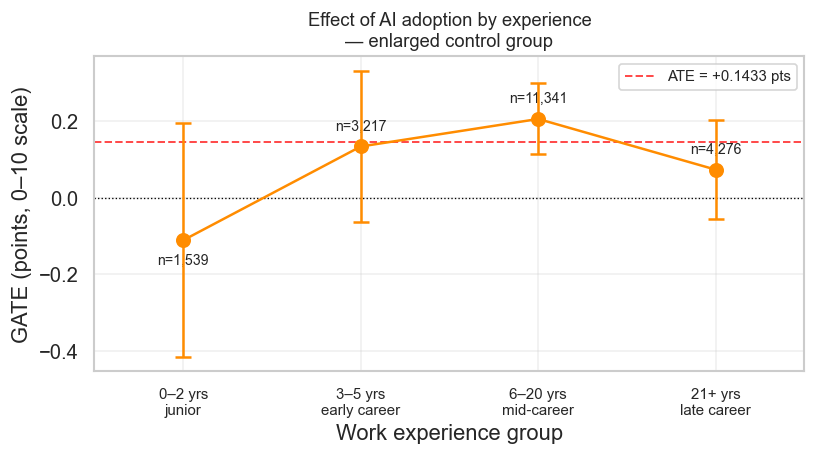

In [26]:
# Robustness figure 1: four-band experience GATE ────────────────────────────
if 'Yr_res' not in dir():
    print("Run the B2 cell above first.")
else:
    from scipy.stats import norm as _norm_r

    # ── Numbers ───────────────────────────────────────────────────────────────
    print("Four-band experience GATE — enlarged control (n=20,373)")
    print(f"  {'Band':12s} {'n':>7s} {'GATE':>10s} {'SE':>7s} {'95% CI':>22s} "
          f"{'z':>6s} {'p':>8s}  sig")
    print("  " + "-" * 82)
    for _, r in res4_rob.iterrows():
        z_f = r['gate'] / r['se']
        p_f = 2 * (1 - _norm_r.cdf(abs(z_f)))
        ci_s = f"[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]"
        print(f"  {str(r['band']):12s} {r['n']:>7,d} {r['gate']:>+10.4f} "
              f"{r['se']:>7.4f} {ci_s:>22s} {z_f:>+6.2f} {p_f:>8.4f}  {r['sig']}")

    # ── Key contrasts ─────────────────────────────────────────────────────────
    print()
    for a, b in [("6-20 yrs", "0-2 yrs"), ("6-20 yrs", "3-5 yrs"),
                 ("6-20 yrs", "21+ yrs"), ("0-2 yrs", "3-5 yrs")]:
        ra = res4_rob[res4_rob['band'] == a].iloc[0]
        rb = res4_rob[res4_rob['band'] == b].iloc[0]
        d  = ra['gate'] - rb['gate']
        se_d = (ra['se']**2 + rb['se']**2)**0.5
        z_d  = d / se_d
        p_d  = 2 * (1 - _norm_r.cdf(abs(z_d)))
        sig_d = '***' if p_d<0.001 else '**' if p_d<0.01 else '*' if p_d<0.05 else 'ns'
        print(f"  {a} vs {b}: diff={d:+.4f} pts  z={z_d:+.2f}  p={p_d:.4f}  {sig_d}")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))

    x4r  = np.arange(len(res4_rob))
    y4r  = res4_rob['gate'].values
    y4lo = res4_rob['ci_lo'].values
    y4hi = res4_rob['ci_hi'].values

    ax.plot(x4r, y4r, color='darkorange', lw=1.5, zorder=3)
    ax.errorbar(x4r, y4r, yerr=[y4r - y4lo, y4hi - y4r],
                fmt='o', color='darkorange', ms=8, capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    for xi, (_, row) in zip(x4r, res4_rob.iterrows()):
        offset = 8 if row['gate'] > 0 else -8
        va = 'bottom' if row['gate'] > 0 else 'top'
        ax.annotate(f"n={int(row['n']):,}",
                    xy=(xi, row['gate']),
                    xytext=(0, offset), textcoords='offset points',
                    fontsize=8.5, ha='center', va=va)

    ax.axhline(0,       color='black', lw=0.8, ls=':')
    ax.axhline(ate_rob, color='red',   lw=1.2, ls='--', alpha=0.7,
               label=f'ATE = {ate_rob:+.4f} pts')

    ax.set_xticks(x4r)
    ax.set_xticklabels(['0\u20132 yrs\njunior', '3\u20135 yrs\nearly career',
                        '6\u201320 yrs\nmid-career', '21+ yrs\nlate career'], fontsize=9)
    ax.set_xlabel('Work experience group')
    ax.set_ylabel('GATE (points, 0\u201310 scale)')
    ax.set_title('Effect of AI adoption by experience\n\u2014 enlarged control group', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.5, 3.5)

    plt.tight_layout()
    plt.savefig(FIGURES / 'cate_by_experience_4band_rob.png', dpi=150, bbox_inches='tight')
    plt.show()

Back-end vs non-back-end by experience — enlarged control
  Band         Role                n      GATE                  95% CI  sig
  ------------------------------------------------------------------------
  0-2 yrs      Back-end          270   -0.2135 pts      [-0.9508, +0.5239]  ns
  0-2 yrs      Non-back-end    1,269   -0.0896 pts      [-0.4240, +0.2449]  ns
  3-5 yrs      Back-end          620   +0.0640 pts      [-0.3299, +0.4578]  ns
  3-5 yrs      Non-back-end    2,597   +0.1487 pts      [-0.0765, +0.3738]  ns
  6-20 yrs     Back-end        2,280   +0.3978 pts      [+0.1841, +0.6115]  ***
  6-20 yrs     Non-back-end    9,061   +0.1520 pts      [+0.0500, +0.2540]  **
  21+ yrs      Back-end          637   +0.0035 pts      [-0.3465, +0.3535]  ns
  21+ yrs      Non-back-end    3,639   +0.0834 pts      [-0.0553, +0.2221]  ns

Pairwise contrasts (back-end vs non-back-end within band):
  0-2 yrs: diff=-0.1239 pts  z=-0.30  p=0.7642  ns
  3-5 yrs: diff=-0.0847 pts  z=-0.37  p=0.7143 

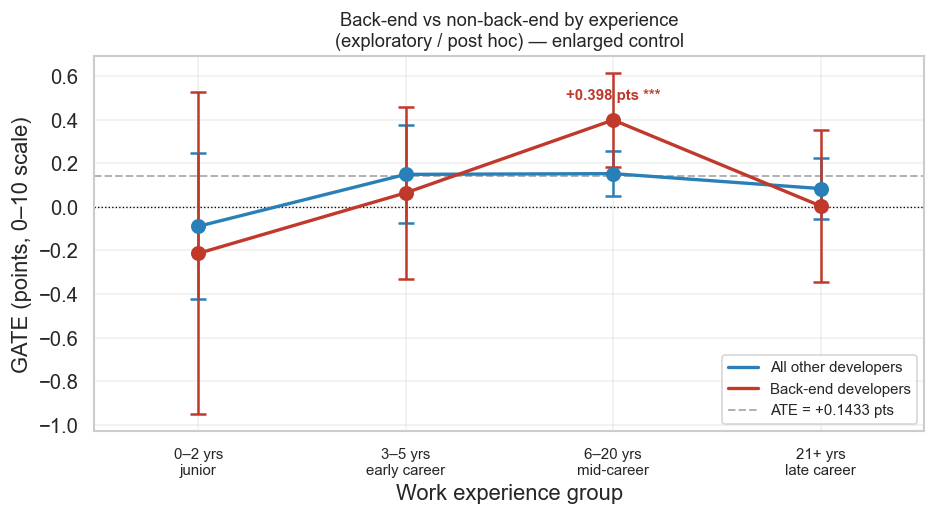

In [27]:
# Robustness figure 2: back-end vs non-back-end by experience ────────────────
if 'Yr_res' not in dir():
    print("Run the B2 cell above first.")
else:
    be_mask_rob    = (df_r2['DevType'] == 'Developer, back-end').values
    nonbe_mask_rob = (~be_mask_rob) & (df_r2['DevType'] != 'Missing')

    rows_int_rob = []
    for grp in EXP4_LABELS:
        exp_m_rob = (eg_rob == grp).values
        for label, mask, role in [
            ('Back-end',     be_mask_rob    & exp_m_rob, 'backend'),
            ('Non-back-end', nonbe_mask_rob & exp_m_rob, 'other'),
        ]:
            res_br = ols_gate(Yr_res[mask], Tr_res[mask], min_n=40)
            if res_br:
                g, s, lo, hi, sig = res_br
                rows_int_rob.append({'exp': grp, 'role': role, 'label': label,
                                     'n': int(mask.sum()), 'gate': g, 'se': s,
                                     'ci_lo': lo, 'ci_hi': hi, 'sig': sig})

    int_rob_df = pd.DataFrame(rows_int_rob)

    # ── Numbers table ─────────────────────────────────────────────────────────
    print("Back-end vs non-back-end by experience — enlarged control")
    print(f"  {'Band':12s} {'Role':14s} {'n':>6s} {'GATE':>9s}  {'95% CI':>22s}  sig")
    print("  " + "-" * 72)
    for _, row in int_rob_df.iterrows():
        ci_s = f"[{row['ci_lo']:+.4f}, {row['ci_hi']:+.4f}]"
        print(f"  {str(row['exp']):12s} {row['label']:14s} {row['n']:>6,d}"
              f"  {row['gate']:>+8.4f} pts  {ci_s:>22s}  {row['sig']}")

    # ── Pairwise contrasts ────────────────────────────────────────────────────
    print()
    print("Pairwise contrasts (back-end vs non-back-end within band):")
    for grp in EXP4_LABELS:
        sb  = int_rob_df[(int_rob_df['exp']==grp) & (int_rob_df['role']=='backend')]
        so  = int_rob_df[(int_rob_df['exp']==grp) & (int_rob_df['role']=='other')]
        if sb.empty or so.empty:
            print(f"  {grp}: skipped (below min_n threshold)")
            continue
        be_r = sb.iloc[0]; oth_r = so.iloc[0]
        d    = be_r['gate'] - oth_r['gate']
        se_d = (be_r['se']**2 + oth_r['se']**2)**0.5
        z_d  = d / se_d
        p_d  = 2 * (1 - _norm.cdf(abs(z_d)))
        s_d  = '***' if p_d<0.001 else '**' if p_d<0.01 else '*' if p_d<0.05 else 'ns'
        print(f"  {grp}: diff={d:+.4f} pts  z={z_d:+.2f}  p={p_d:.4f}  {s_d}")

    # ── Figure ────────────────────────────────────────────────────────────────
    x4_ord_r  = np.arange(4)
    e4_to_x_r = {lbl: xi for xi, lbl in zip(x4_ord_r, EXP4_LABELS)}
    colors_r  = {'backend': '#c0392b', 'other': '#2980b9'}
    lbl_r     = {'backend': 'Back-end developers', 'other': 'All other developers'}

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for role in ['other', 'backend']:
        sub = int_rob_df[int_rob_df['role'] == role]
        if sub.empty:
            continue
        xv  = np.array([e4_to_x_r[e] for e in sub['exp']])
        yv  = sub['gate'].values
        lov = sub['ci_lo'].values
        hiv = sub['ci_hi'].values
        c_r = colors_r[role]

        ax.plot(xv, yv, color=c_r, lw=2, zorder=3, label=lbl_r[role])
        ax.errorbar(xv, yv, yerr=[yv - lov, hiv - yv],
                    fmt='o', color=c_r, ms=8, capsize=5, capthick=1.5,
                    elinewidth=1.5, zorder=4)

        if role == 'backend':
            mc = sub[sub['exp'] == '6-20 yrs']
            if not mc.empty:
                r  = mc.iloc[0]
                xi = e4_to_x_r['6-20 yrs']
                stars = f" {r['sig']}" if r['sig'] != 'ns' else ''
                ax.annotate(f"{r['gate']:+.3f} pts{stars}",
                            xy=(xi, r['gate']), xytext=(0, 12),
                            textcoords='offset points',
                            fontsize=9, ha='center', color=c_r, fontweight='bold')

    ax.axhline(0,       color='black', lw=0.8, ls=':')
    ax.axhline(ate_rob, color='gray',  lw=1.2, ls='--', alpha=0.6,
               label=f'ATE = {ate_rob:+.4f} pts')

    ax.set_xticks(x4_ord_r)
    ax.set_xticklabels(['0\u20132 yrs\njunior', '3\u20135 yrs\nearly career',
                        '6\u201320 yrs\nmid-career', '21+ yrs\nlate career'], fontsize=9)
    ax.set_xlabel('Work experience group')
    ax.set_ylabel('GATE (points, 0\u201310 scale)')
    ax.set_title('Back-end vs non-back-end by experience\n'
                 '(exploratory / post hoc) \u2014 enlarged control', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.5, 3.5)

    plt.tight_layout()
    plt.savefig(FIGURES / 'gate_backend_x_experience_4band_rob.png', dpi=150, bbox_inches='tight')
    plt.show()

## Methods Notes (for thesis Methods section)

### 3.1 Identification Strategy

This study uses **Double / Debiased Machine Learning** (DML; Chernozhukov et al. 2018)
to estimate the average causal effect of AI tool adoption on developer job satisfaction,
under **conditional ignorability** (selection on observables):

$$Y(1), Y(0) \perp T \mid X$$

The observed covariate vector $X$ includes demographics, experience, compensation,
organisation, role, and country. This is a strong assumption: unobserved factors
such as technology enthusiasm, growth mindset, or employer AI culture could confound
the estimate. The E-value analysis (Step 10D) shows that a confounder of only moderate
strength (~1.3× risk-ratio scale) would be sufficient to explain away the ATE,
reflecting the low R² of the outcome nuisance model (0.004).

### 3.2 Double ML Estimator

The **partially linear regression** (PLR) model is:

$$Y_i = \theta \cdot T_i + g(X_i) + \varepsilon_i, \quad \mathbb{E}[\varepsilon_i \mid T_i, X_i] = 0$$

**Estimation procedure** (5-fold cross-fitting):
1. Fit LightGBM nuisance models on training folds → $\hat{g}^{(-k)}(X_i)$ and $\hat{m}^{(-k)}(X_i)$
2. Compute residuals $\tilde{Y}_i = Y_i - \hat{g}^{(-k)}(X_i)$, $\tilde{T}_i = T_i - \hat{m}^{(-k)}(X_i)$
3. Estimate $\hat{\theta}$ via OLS of $\tilde{Y}$ on $\tilde{T}$ with HC3 standard errors

### 3.3 Effect Size and Practical Significance

The estimated ATE is **+0.124 JobSat points** (Cohen's d ≈ 0.065), which is
statistically significant (p = 0.001) but trivially small in practical terms
(below the conventional d = 0.2 threshold for a 'small' effect).
Statistical significance is partly a function of the large sample (N = 19,320).
**The primary contribution of this study is not the average effect but the
heterogeneity analysis**: for whom and under what conditions does AI adoption matter?

### 3.4 Causal Forest and Group Inference

**CausalForestDML** (Athey et al. 2019) estimates individual CATEs $\tau(X_i)$.
Group-level estimates (by experience, org size) use the group mean CATE with
standard error $\hat{\sigma}_{G} = \text{SD}(\hat{\tau}_G) / \sqrt{n_G}$,
which gives proper group-level inference rather than averaging individual CIs.

The BLP F-test confirms that CATE heterogeneity is statistically significant
(F = 65.9, p < 0.001, R² = 0.035). However, missing-value indicators
(WorkExp_missing, CompLog_missing) are among the strongest BLP predictors,
suggesting that some apparent heterogeneity reflects non-response patterns.
The robustness BLP (Step 10B) confirms that CompLog and Age remain significant
after excluding these indicators.

### 3.5 Hypotheses and Findings

| Hypothesis | Prediction | Finding |
|---|---|---|
| H1a | Juniors (≤5 yrs) benefit most | **Rejected** — juniors show negative CATE (−0.06) |
| H1b | Seniors (≥10 yrs) near-zero | **Rejected** — 16–20 yr group has highest CATE (+0.28) |
| H2  | Effect increases with org size | **Weak support** — positive gradient, not monotone |

The reversal of H1a/H1b is the most substantively interesting finding.
A possible explanation consistent with the JD-R framework: experienced developers
possess the technical judgment to selectively adopt AI for demand-reducing tasks,
while junior developers may experience AI as *demand-creating* (debugging AI errors,
verifying suggestions, managing uncertainty about code quality).

### 3.6 Sensitivity and Limitations

1. **E-value ≈ 1.3**: The ATE is fragile to unmeasured confounding of moderate strength.
2. **R² = 0.004**: Covariates explain almost none of JobSat variance, limiting adjustment power.
3. **Cross-sectional data**: Reverse causality possible (happier developers may adopt AI differently).
4. **Self-selected sample**: Stack Overflow users are not representative of all developers.
5. **Propensity imbalance**: 82.7% treatment rate; 11.6% have extreme propensity scores (PS > 0.95).

### 3.7 Sample and Covariates

| Group | Variables |
|---|---|
| Ordinal | OrgSize (0–7), Age (0–7), EdLevel (0–6) |
| Numeric | WorkExp, YearsCode, CompLog |
| Missing indicators | WorkExp_missing, YearsCode_missing, CompLog_missing |
| Nominal (one-hot) | DevType, Country (rare→Other), Industry, RemoteWork, ICorPM |
